# Day 3: Customer Journey Analysis

## Business Question

**How should customer journeys be reconstructed and measured to evaluate the new website?**

## Objective

The objective of this notebook is to reconstruct customer journeys from the cleaned web event data, define consistent measurement rules, and calculate the KPIs required to evaluate customer behaviour during the Vanguard A/B test.

The methodology will be defined before calculating the KPIs so that the analysis remains transparent, consistent and reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os

print(os.getcwd())

/Users/jannoelvero/Documents/Ironhack/week_6/Week_6_Project


In [4]:
web_clean_df = pd.read_csv(
    "data/processed/web_clean.csv",
    parse_dates=["date_time"]
)

experiment_clients_df = pd.read_csv(
    "data/processed/experiment_clients.csv"
)

## 1. Explore and Reconstruct Customer Journeys

In [5]:
print("Web data shape:", web_clean_df.shape)
print("Experiment clients shape:", experiment_clients_df.shape)

display(web_clean_df.head())
display(experiment_clients_df.head())

Web data shape: (744641, 8)
Experiment clients shape: (70609, 2)


,client_id,visitor_id,visit_id,process_step,date_time,step_number,previous_step,backward_navigation
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,0,NaN,False
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,1,0.0,False
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,2,1.0,False
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,3,2.0,False
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,4,3.0,False


,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [6]:
web_clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 744641 entries, 0 to 744640
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   client_id            744641 non-null  int64         
 1   visitor_id           744641 non-null  str           
 2   visit_id             744641 non-null  str           
 3   process_step         744641 non-null  str           
 4   date_time            744641 non-null  datetime64[us]
 5   step_number          744641 non-null  int64         
 6   previous_step        585529 non-null  float64       
 7   backward_navigation  744641 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 40.5 MB


# Summarize repeated steps and backward navigation

In [30]:
print(
    "Visits with backward navigation:",
    journey_df["backward_navigation"].sum()
)

print(
    "Percentage with backward navigation:",
    round(
        journey_df["backward_navigation"].mean() * 100,
        2
    ),
    "%"
)

Visits with backward navigation: 39883
Percentage with backward navigation: 25.23 %


In [31]:
for step in ["step_1", "step_2", "step_3"]:
    repeated = (event_counts[step] > 1).sum()
    
    print(
        step,
        repeated,
        round(repeated / total_visits * 100, 2),
        "%"
    )

step_1 29725 18.8 %
step_2 18953 11.99 %
step_3 12025 7.61 %


# Common journey patterns

In [32]:
journey_patterns = (
    journey_sequences
    .apply(lambda x: " → ".join(x))
    .value_counts()
    .head(10)
)

journey_patterns

process_step
start → step_1 → step_2 → step_3 → confirm                     46129
start                                                          16749
start → step_1                                                  8178
confirm                                                         7982
start → start                                                   6027
start → step_1 → step_2 → step_3                                4497
start → step_1 → start → step_1 → step_2 → step_3 → confirm     4034
start → step_1 → step_2                                         3772
start → start → step_1 → step_2 → step_3 → confirm              3038
start → step_1 → step_2 → step_3 → confirm → confirm            2666
Name: count, dtype: int64

In [33]:
journey_patterns_df = journey_patterns.reset_index()

journey_patterns_df.columns = [
    "journey_pattern",
    "number_of_visits"
]

journey_patterns_df["percentage"] = (
    journey_patterns_df["number_of_visits"]
    / total_visits
    * 100
)

journey_patterns_df.round(2)

,journey_pattern,number_of_visits,percentage
0,start → step_1 → step_2 → step_3 → confirm,46129,29.18
1,start,16749,10.59
2,start → step_1,8178,5.17
3,confirm,7982,5.05
4,start → start,6027,3.81
5,start → step_1 → step_2 → step_3,4497,2.84
6,start → step_1 → start → step_1 → step_2 → ste...,4034,2.55
7,start → step_1 → step_2,3772,2.39
8,start → start → step_1 → step_2 → step_3 → con...,3038,1.92
9,start → step_1 → step_2 → step_3 → confirm → c...,2666,1.69


### Journey Pattern Analysis

The reconstructed journeys show that customers do not always follow the expected process in a simple linear sequence.

The most common exact journey pattern was:

**start → step_1 → step_2 → step_3 → confirm**

This occurred in **46,129 visits, representing 29.18% of all visits**.

Several common patterns represent incomplete journeys. For example, **10.59% of visits contained only a start event**, while other customers stopped after `step_1`, `step_2`, or `step_3`.

Nonstandard behaviour was also common. Approximately **25.23% of visits contained backward navigation**.

Repeated intermediate steps occurred in:

* `step_1`: **18.80% of visits**
* `step_2`: **11.99% of visits**
* `step_3`: **7.61% of visits**

The frequency of repeated steps decreases as customers progress through the process, suggesting that friction or repeated interaction is more common during the earlier stages of the journey.

Restart behaviour is also visible among the most common journey patterns. For example, sequences containing repeated `start` events before eventually progressing to confirmation occur frequently.

Repeated confirmation is also present. The sequence:

**start → step_1 → step_2 → step_3 → confirm → confirm**

was observed in **2,666 visits, or 1.69% of all visits**.

A `confirm` only sequence was observed in **7,982 visits, or 5.05% of all visits**. These visits cannot be interpreted as complete observed start to confirm journeys because the beginning of the process is not present in the recorded session.

Overall, the journey data contains meaningful incomplete journeys, restarts, repeated steps, backward navigation and repeated confirmations. These behaviours should therefore be measured rather than automatically removed as data errors.

### Task 1 Conclusion

Customer journeys show substantial variation beyond the expected linear process.

Although the standard `start → step_1 → step_2 → step_3 → confirm` sequence is the most common exact pattern, it represents only **29.18% of all visits**. Incomplete journeys, repeated starts, repeated intermediate steps, backward navigation and repeated confirmations occur frequently.

This confirms that KPI definitions must account for actual customer behaviour rather than assuming that every visit follows the expected process.

The reconstruction methodology has therefore been designed to preserve meaningful customer behaviour while applying consistent rules for determining valid completion and measuring successful journeys.

With these rules established and validated, the reconstructed journey data is ready for KPI definition and computation.

## 2. Customer Journey Reconstruction

### Purpose

The web dataset contains individual events rather than one row per completed customer journey.

Before calculating KPIs, events must be grouped and ordered so that each customer's progression through the digital process can be evaluated correctly.

A journey is defined at the `visit_id` level because `visit_id` represents an individual web session. Events within each visit are ordered chronologically using `date_time`.

The expected process sequence is:

**start → step_1 → step_2 → step_3 → confirm**

Before applying KPI rules to the full dataset, representative journeys will be inspected manually to understand normal progression, incomplete journeys, repeated steps and backward navigation.

# Confirm the expected process steps

In [7]:
web_clean_df["process_step"].value_counts()

process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

In [8]:
web_clean_df["step_number"].value_counts().sort_index()

step_number
0    234999
1    162797
2    132750
3    111589
4    102506
Name: count, dtype: int64

# Confirm visit ownership

In [9]:
clients_per_visit = (
    web_clean_df
    .groupby("visit_id")["client_id"]
    .nunique()
)

print("Total visits:", clients_per_visit.size)

print(
    "Visits linked to more than one client:",
    (clients_per_visit > 1).sum()
)

Total visits: 158095
Visits linked to more than one client: 1012


# Inspect representative journeys

In [10]:
journey_sequences = (
    web_clean_df
    .sort_values(["visit_id", "date_time"])
    .groupby("visit_id")["process_step"]
    .apply(list)
)

journey_sequences.head(10)

visit_id
100012776_37918976071_457913                                   [confirm, confirm]
1000165_4190026492_760066                [start, step_1, step_2, step_3, confirm]
100019538_17884295066_43909     [start, step_1, step_2, step_1, step_1, start,...
100022086_87870757897_149620             [start, step_1, step_2, step_3, confirm]
100030127_47967100085_936361                                              [start]
100034012_10293842356_627828    [start, step_1, start, step_1, step_2, step_3,...
100037962_47432393712_705583                        [start, start, step_1, start]
100057941_88477660212_944512    [start, step_1, step_2, step_3, step_1, step_2...
100061345_677868293_127105                                                [start]
100064169_21178362056_671035                                              [start]
Name: process_step, dtype: object

# Quantify journey structures

# Total number of visits

In [11]:
total_visits = web_clean_df["visit_id"].nunique()

print("Total visits:", total_visits)

Total visits: 158095


# Visits containing start and confirm

In [12]:
visit_summary = (
    web_clean_df
    .groupby("visit_id")
    .agg(
        client_id=("client_id", "first"),
        has_start=("process_step", lambda x: (x == "start").any()),
        has_confirm=("process_step", lambda x: (x == "confirm").any()),
        event_count=("process_step", "size")
    )
    .reset_index()
)

visit_summary.head()

,visit_id,client_id,has_start,has_confirm,event_count
0,100012776_37918976071_457913,3561384,False,True,2
1,1000165_4190026492_760066,9056452,True,True,5
2,100019538_17884295066_43909,7338123,True,True,11
3,100022086_87870757897_149620,2478628,True,True,5
4,100030127_47967100085_936361,105007,True,False,1


In [13]:
print(
    "Visits with start:",
    visit_summary["has_start"].sum()
)

print(
    "Visits with confirm:",
    visit_summary["has_confirm"].sum()
)

print(
    "Visits with both start and confirm:",
    (
        visit_summary["has_start"]
        & visit_summary["has_confirm"]
    ).sum()
)

print(
    "Confirm but no start:",
    (
        ~visit_summary["has_start"]
        & visit_summary["has_confirm"]
    ).sum()
)

print(
    "Start but no confirm:",
    (
        visit_summary["has_start"]
        & ~visit_summary["has_confirm"]
    ).sum()
)

Visits with start: 144902
Visits with confirm: 89826
Visits with both start and confirm: 77330
Confirm but no start: 12496
Start but no confirm: 67572


# Validate Start Before Confirm
Determine how many visits contain at least one valid chronological path from start to confirm.

In [14]:
first_start = (
    web_clean_df[web_clean_df["process_step"] == "start"]
    .groupby("visit_id")["date_time"]
    .min()
)

last_confirm = (
    web_clean_df[web_clean_df["process_step"] == "confirm"]
    .groupby("visit_id")["date_time"]
    .max()
)

start_confirm_check = pd.concat(
    [first_start, last_confirm],
    axis=1
)

start_confirm_check.columns = [
    "first_start",
    "last_confirm"
]

start_confirm_check["valid_order"] = (
    start_confirm_check["first_start"]
    < start_confirm_check["last_confirm"]
)

start_confirm_check.head()

,first_start,last_confirm,valid_order
visit_id,,,
1000165_4190026492_760066,2017-06-04 01:07:29,2017-06-04 01:09:50,True
100019538_17884295066_43909,2017-04-09 16:20:56,2017-04-09 16:24:58,True
100022086_87870757897_149620,2017-05-23 20:44:01,2017-05-23 20:47:01,True
100030127_47967100085_936361,2017-03-22 11:07:49,NaT,False
100034012_10293842356_627828,2017-06-06 14:04:44,2017-06-06 14:08:29,True


In [15]:
both_events = start_confirm_check.dropna()

print("Visits with both start and confirm:", len(both_events))

print(
    "Start before confirm:",
    both_events["valid_order"].sum()
)

print(
    "Invalid order:",
    (~both_events["valid_order"]).sum()
)

Visits with both start and confirm: 77330
Start before confirm: 77267
Invalid order: 63


### Start and Confirm Order Validation

Among the 77,330 visits containing both a `start` and a `confirm` event, 77,267 visits had at least one chronological path in which `start` occurred before `confirm`.

Only 63 visits contained both events without satisfying this chronological condition.

This confirms that simply observing both events is not sufficient to define a valid completion. Event order must also be considered.

### Decision

A visit will be classified as a **valid completed journey** when:

1. The visit contains an observed `start`.
2. The visit contains an observed `confirm`.
3. At least one `start` occurs before a `confirm`.

Visits containing `start` but no subsequent `confirm` will be classified as incomplete journeys.

Visits containing `confirm` without an observed `start` will remain in the source data but will not be counted as valid completed journeys for start based completion KPIs.

The 63 visits containing both events without a valid chronological start to confirm sequence will also be excluded from valid completion.

Repeated steps, repeated starts, repeated confirms and backward navigation will not automatically invalidate a journey because these behaviours may represent genuine customer interaction and potential digital friction.

## Quantify multiple starts and confirms

In [16]:
event_counts = (
    web_clean_df
    .groupby(["visit_id", "process_step"])
    .size()
    .unstack(fill_value=0)
)

event_counts.head()

process_step,confirm,start,step_1,step_2,step_3
visit_id,,,,,
100012776_37918976071_457913,2,0,0,0,0
1000165_4190026492_760066,1,1,1,1,1
100019538_17884295066_43909,1,3,4,2,1
100022086_87870757897_149620,1,1,1,1,1
100030127_47967100085_936361,0,1,0,0,0


In [17]:
multiple_starts = (event_counts["start"] > 1).sum()
multiple_confirms = (event_counts["confirm"] > 1).sum()

print("Visits with multiple starts:", multiple_starts)
print("Visits with multiple confirms:", multiple_confirms)

print(
    "Percentage with multiple starts:",
    round(multiple_starts / total_visits * 100, 2),
    "%"
)

print(
    "Percentage with multiple confirms:",
    round(multiple_confirms / total_visits * 100, 2),
    "%"
)

Visits with multiple starts: 50314
Visits with multiple confirms: 8923
Percentage with multiple starts: 31.83 %
Percentage with multiple confirms: 5.64 %


### Multiple Start and Confirm Events

The journey data contains substantial repeated activity.

A total of **50,314 visits, or 31.83% of all visits, contain more than one `start` event**. In addition, **8,923 visits, or 5.64%, contain more than one `confirm` event**.

Multiple starts are therefore a common feature of the observed customer journeys rather than a rare anomaly.

### Decision

Repeated `start` and `confirm` events will be retained because they may represent genuine customer behaviour such as restarting the process, retrying an action or continuing after interruption.

They will not automatically invalidate a visit.

However, the first `start` and last `confirm` will not automatically be used to calculate completion time because this could exaggerate the duration of journeys containing restarts or repeated confirmations.

A consistent start to completion pairing rule will therefore be established before calculating time based KPIs.

In [18]:
valid_visit_ids = both_events[
    both_events["valid_order"]
].index

valid_event_counts = event_counts.loc[
    event_counts.index.isin(valid_visit_ids)
]

print(
    "Valid completed visits:",
    len(valid_event_counts)
)

print(
    "Completed visits with multiple starts:",
    (valid_event_counts["start"] > 1).sum()
)

print(
    "Completed visits with multiple confirms:",
    (valid_event_counts["confirm"] > 1).sum()
)

Valid completed visits: 77267
Completed visits with multiple starts: 19450
Completed visits with multiple confirms: 6492


In [19]:
completed_multiple_starts = (
    valid_event_counts["start"] > 1
).sum()

completed_multiple_confirms = (
    valid_event_counts["confirm"] > 1
).sum()

print(
    "Completed visits with multiple starts:",
    round(
        completed_multiple_starts
        / len(valid_event_counts)
        * 100,
        2
    ),
    "%"
)

print(
    "Completed visits with multiple confirms:",
    round(
        completed_multiple_confirms
        / len(valid_event_counts)
        * 100,
        2
    ),
    "%"
)

Completed visits with multiple starts: 25.17 %
Completed visits with multiple confirms: 8.4 %


### Repeated Events Within Completed Journeys

Among the 77,267 valid completed visits, **25.17% contained multiple start events** and **8.40% contained multiple confirm events**.

This means repeated activity is also common among customers who eventually complete the process.

Using the first start and last confirm would combine multiple attempts in some visits and could overestimate completion time.

### Decision

For time based completion metrics, the analysis will use:

**Completion event:** The first valid `confirm` event.

**Start event:** The most recent `start` occurring before that first valid `confirm`.

This approach measures the customer's final observed attempt leading to completion rather than combining earlier abandoned or restarted attempts with the successful attempt.

Events occurring after the selected first valid `confirm` will not contribute to completion time because the customer has already reached the completion point.

Repeated events and earlier attempts will remain available for friction and error analysis rather than being deleted from the source data.

## Implement the rule
calculate the selected start and confirm timestamps for each valid completed visit.

In [23]:
# Sort events chronologically
completed_events = (
    web_clean_df[
        web_clean_df["visit_id"].isin(valid_visit_ids)
    ]
    .sort_values(["visit_id", "date_time"])
    .copy()
)

# Find the first start in each visit
first_start = (
    completed_events[
        completed_events["process_step"] == "start"
    ]
    .groupby("visit_id")["date_time"]
    .min()
    .rename("first_start")
)

# Add first start to the event data
completed_events = completed_events.merge(
    first_start,
    on="visit_id",
    how="left"
)

# Keep confirm events that occur after a start
valid_confirms = completed_events[
    (completed_events["process_step"] == "confirm")
    & (completed_events["date_time"] > completed_events["first_start"])
]

# Select the first valid confirm
first_valid_confirm = (
    valid_confirms
    .groupby("visit_id")["date_time"]
    .min()
    .rename("completion_time")
)

# Add the valid completion time
completed_events = completed_events.merge(
    first_valid_confirm,
    on="visit_id",
    how="left"
)

# Find the most recent start before the valid confirm
valid_starts = completed_events[
    (completed_events["process_step"] == "start")
    & (completed_events["date_time"] < completed_events["completion_time"])
]

selected_start = (
    valid_starts
    .groupby("visit_id")["date_time"]
    .max()
    .rename("selected_start_time")
)

# Create the final completion pairs
completion_pairs = pd.concat(
    [selected_start, first_valid_confirm],
    axis=1
).reset_index()

completion_pairs.head(10)

,visit_id,selected_start_time,completion_time
0,1000165_4190026492_760066,2017-06-04 01:07:29,2017-06-04 01:09:50
1,100019538_17884295066_43909,2017-04-09 16:21:59,2017-04-09 16:24:58
2,100022086_87870757897_149620,2017-05-23 20:44:01,2017-05-23 20:47:01
3,100034012_10293842356_627828,2017-06-06 14:06:15,2017-06-06 14:08:29
4,100065579_58979991824_496649,2017-04-15 14:27:50,2017-04-15 14:33:28
5,10006594_66157970412_679648,2017-04-13 11:50:18,2017-04-13 11:56:12
6,100075378_35009209505_135399,2017-06-03 19:55:37,2017-06-03 20:15:31
7,10007589_47780784567_391490,2017-05-18 07:51:32,2017-05-18 08:03:33
8,100100247_25668133240_318122,2017-06-03 16:16:49,2017-06-03 16:21:40
9,100154767_60541320490_163313,2017-03-29 13:35:15,2017-03-29 13:41:44


In [24]:
print("Valid completed visits:", len(valid_visit_ids))
print("Completion pairs created:", len(completion_pairs))

print(
    "Missing selected starts:",
    completion_pairs["selected_start_time"].isna().sum()
)

print(
    "Missing completion times:",
    completion_pairs["completion_time"].isna().sum()
)

Valid completed visits: 77267
Completion pairs created: 77267
Missing selected starts: 0
Missing completion times: 0


### Final Start and Completion Pairing Rule

A valid completion requires an observed `start` followed chronologically by a `confirm`.

When multiple events occur within a visit:

1. The first `confirm` occurring after at least one observed `start` is selected as the completion event.
2. The most recent `start` occurring before that selected confirmation is used as the beginning of the successful completion attempt.
3. Earlier starts are treated as previous attempts or restart behaviour.
4. Confirm events occurring before an observed start are not treated as valid completions for that journey.
5. Confirm events occurring after the selected valid confirmation are retained in the event data but do not extend completion time.

This rule prevents earlier attempts and repeated confirmations from artificially increasing completion time while preserving those events for later friction and error analysis.

# Validation Result

The final pairing method successfully created start and completion timestamps for all **77,267 valid completed visits**, with no missing start or completion timestamps.

This confirms that the reconstruction rule handles repeated starts, repeated confirmations and confirmations occurring before an observed start consistently.

The validated start and completion pairs can therefore be used for subsequent journey KPI calculations.

### Journey Level Dataset
The original web_clean_df contains one row per event. KPI analysis requires a visit level dataset where each row represents one customer journey.

journey_df = (
    web_clean_df
    .groupby("visit_id")
    .agg(
        client_id=("client_id", "first"),
        visitor_id=("visitor_id", "first"),
        first_event=("date_time", "min"),
        last_event=("date_time", "max"),
        event_count=("process_step", "size"),
        has_start=("process_step", lambda x: (x == "start").any()),
        has_confirm=("process_step", lambda x: (x == "confirm").any()),
        backward_navigation=("backward_navigation", "any")
    )
    .reset_index()
)

journey_df.head()

In [26]:
journey_df = journey_df.merge(
    completion_pairs,
    on="visit_id",
    how="left"
)

journey_df["completed"] = (
    journey_df["completion_time"].notna()
)

journey_df.head()

,visit_id,client_id,visitor_id,first_event,last_event,event_count,has_start,has_confirm,backward_navigation,selected_start_time,completion_time,completed
0,100012776_37918976071_457913,3561384,451664975_1722933822,2017-04-26 13:22:17,2017-04-26 13:23:09,2,False,True,False,NaT,NaT,False
1,1000165_4190026492_760066,9056452,306992881_89423906595,2017-06-04 01:07:29,2017-06-04 01:09:50,5,True,True,False,2017-06-04 01:07:29,2017-06-04 01:09:50,True
2,100019538_17884295066_43909,7338123,612065484_94198474375,2017-04-09 16:20:56,2017-04-09 16:24:58,11,True,True,True,2017-04-09 16:21:59,2017-04-09 16:24:58,True
3,100022086_87870757897_149620,2478628,754122351_18568832435,2017-05-23 20:44:01,2017-05-23 20:47:01,5,True,True,False,2017-05-23 20:44:01,2017-05-23 20:47:01,True
4,100030127_47967100085_936361,105007,676020267_36602664238,2017-03-22 11:07:49,2017-03-22 11:07:49,1,True,False,False,NaT,NaT,False


In [27]:
journey_df = journey_df.merge(
    experiment_clients_df,
    on="client_id",
    how="left"
)

journey_df.head()

,visit_id,client_id,visitor_id,first_event,last_event,event_count,has_start,has_confirm,backward_navigation,selected_start_time,completion_time,completed,Variation
0,100012776_37918976071_457913,3561384,451664975_1722933822,2017-04-26 13:22:17,2017-04-26 13:23:09,2,False,True,False,NaT,NaT,False,Test
1,1000165_4190026492_760066,9056452,306992881_89423906595,2017-06-04 01:07:29,2017-06-04 01:09:50,5,True,True,False,2017-06-04 01:07:29,2017-06-04 01:09:50,True,NaN
2,100019538_17884295066_43909,7338123,612065484_94198474375,2017-04-09 16:20:56,2017-04-09 16:24:58,11,True,True,True,2017-04-09 16:21:59,2017-04-09 16:24:58,True,Test
3,100022086_87870757897_149620,2478628,754122351_18568832435,2017-05-23 20:44:01,2017-05-23 20:47:01,5,True,True,False,2017-05-23 20:44:01,2017-05-23 20:47:01,True,Test
4,100030127_47967100085_936361,105007,676020267_36602664238,2017-03-22 11:07:49,2017-03-22 11:07:49,1,True,False,False,NaT,NaT,False,Control


Validate the new dataset

In [28]:
print("Journey rows:", len(journey_df))
print("Unique visits:", journey_df["visit_id"].nunique())
print("Unique clients:", journey_df["client_id"].nunique())

print(
    "Valid completed journeys:",
    journey_df["completed"].sum()
)

print("\nExperimental groups:")
print(journey_df["Variation"].value_counts(dropna=False))

Journey rows: 158095
Unique visits: 158095
Unique clients: 119355
Valid completed journeys: 77267

Experimental groups:
Variation
NaN        89071
Test       36990
Control    32034
Name: count, dtype: int64


In [29]:
journey_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158095 entries, 0 to 158094
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   visit_id             158095 non-null  str           
 1   client_id            158095 non-null  int64         
 2   visitor_id           158095 non-null  str           
 3   first_event          158095 non-null  datetime64[us]
 4   last_event           158095 non-null  datetime64[us]
 5   event_count          158095 non-null  int64         
 6   has_start            158095 non-null  bool          
 7   has_confirm          158095 non-null  bool          
 8   backward_navigation  158095 non-null  bool          
 9   selected_start_time  77267 non-null   datetime64[us]
 10  completion_time      77267 non-null   datetime64[us]
 11  completed            158095 non-null  bool          
 12  Variation            69024 non-null   str           
dtypes: bool(4), datetime64[us

### Journey Level Dataset Validation

The event level web data was transformed into a journey level analytical dataset containing **158,095 visits from 119,355 clients**.

Each row now represents one unique `visit_id`. The number of rows exactly matches the number of unique visits, confirming that the dataset is correctly structured at the visit level.

Using the validated completion rule, **77,267 visits were classified as valid completed journeys**.

Experimental assignment was available for **69,024 visits**, consisting of:

* **36,990 Test visits**
* **32,034 Control visits**

The remaining **89,071 visits** belong to clients without a Control or Test assignment in the experiment roster.

### Decision

`journey_df` will be retained as the master journey level dataset.

Visits without an experimental assignment will not be deleted because they remain valid observed customer journeys. However, they will be excluded when comparing Control and Test performance because they cannot be attributed to either experimental condition.

This separates data retention from experimental eligibility and prevents unassigned customers from affecting the A/B test comparison.

### Treatment of Exceptionally Long Journeys

Before defining how exceptionally long journeys will be handled, the distribution of completion time is examined using the reconstructed completion interval.

Completion time is measured from the most recent valid start before the first valid confirmation.

The IQR method is used to identify unusually long completion times. These observations will be investigated before deciding whether they should be retained, excluded, or handled using robust summary statistics.

In [34]:
completion_pairs["completion_minutes"] = (
    completion_pairs["completion_time"]
    - completion_pairs["selected_start_time"]
).dt.total_seconds() / 60

completion_pairs["completion_minutes"].describe()

count    77267.000000
mean         4.962299
std          4.813779
min          0.083333
25%          2.316667
50%          3.516667
75%          5.766667
max        105.583333
Name: completion_minutes, dtype: float64

In [35]:
q1 = completion_pairs["completion_minutes"].quantile(0.25)
q3 = completion_pairs["completion_minutes"].quantile(0.75)

iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Upper bound:", round(upper_bound, 2))

Q1: 2.32
Q3: 5.77
IQR: 3.45
Upper bound: 10.94


In [36]:
long_completion = completion_pairs[
    completion_pairs["completion_minutes"] > upper_bound
]

print("Exceptionally long completed journeys:", len(long_completion))

print(
    "Percentage:",
    round(
        len(long_completion)
        / len(completion_pairs)
        * 100,
        2
    ),
    "%"
)

print(
    "Maximum completion time:",
    round(completion_pairs["completion_minutes"].max(), 2),
    "minutes"
)

Exceptionally long completed journeys: 6059
Percentage: 7.84 %
Maximum completion time: 105.58 minutes


### Interpretation and Decision

Completion time is right skewed. The median completion time is approximately **3.52 minutes**, while the mean is higher at approximately **4.96 minutes**.

Using the IQR method, completion times above **10.94 minutes** are classified as unusually long. A total of **6,059 completed journeys, or 7.84%, exceed this threshold**, with a maximum observed completion time of approximately **105.58 minutes**.

These journeys will **not be automatically removed**.

Long completion times may reflect genuine customer behaviour such as hesitation, interruptions, temporary inactivity, or slower progression through the process. Duration alone does not provide sufficient evidence that these observations are invalid.

### Methodological Decision

All valid completed journeys will remain in the analytical dataset.

For completion time analysis:

1. Median completion time will be used as the primary measure of typical customer experience because it is less sensitive to the right skew and unusually long journeys.
2. The IQR will be used to describe the spread of completion times.
3. Mean completion time may also be reported for completeness, but it will be interpreted cautiously because it is influenced by the long right tail.
4. Journeys above the IQR upper threshold will be retained and identified as unusually long rather than deleted.
5. Sensitivity to these long journeys will be acknowledged when interpreting Control and Test differences.

## Task 2 Final Analytical Methodology

Before calculating the project KPIs, a consistent analytical methodology was established to determine how customer behaviour will be measured.

### Analytical Unit

The primary analytical unit is the **visit level customer journey**.

Each `visit_id` represents one observed attempt to progress through the Vanguard digital process. Events within each visit are ordered chronologically using `date_time`.

The same client may therefore contribute more than one journey if multiple visits are observed.

### Multiple Visits From the Same Client

Multiple visits from the same client are treated as separate customer journeys.

This decision preserves information about repeated attempts, abandonment, later successful completion, and changes in customer behaviour across sessions.

The `client_id` remains available so that repeated journeys from the same customer can still be identified when required.

### Incomplete Journeys

A journey containing an observed `start` but no subsequent valid `confirm` is classified as incomplete.

Incomplete journeys are retained because they represent meaningful customer outcomes and are required for measures such as Completion Rate, Funnel Conversion and Abandonment Rate.

Incomplete journeys are excluded from Completion Time because a valid completion timestamp does not exist.

### Valid Completion

A valid completed journey requires an observed `start` followed chronologically by a `confirm`.

When multiple starts or confirmations occur:

1. The first valid `confirm` occurring after an observed start represents completion.
2. The most recent `start` before that confirmation represents the beginning of the successful attempt.

This prevents earlier abandoned attempts or repeated confirmations from artificially increasing completion time.

### Repeated Events

Repeated starts, intermediate steps and confirmations are retained.

Repeated events may indicate retries, hesitation, restarting or other genuine customer behaviour and therefore provide useful evidence about friction within the digital journey.

They are not automatically treated as data errors.

### Backward Navigation

Backward navigation is retained and flagged.

Because approximately **25.23% of visits contain backward navigation**, it is treated as a meaningful behavioural characteristic rather than a rare anomaly.

Backward movements will contribute to the Step Backs KPI and may also provide evidence of digital friction.

### Exceptionally Long Journeys

Completion times above the IQR upper threshold of **10.94 minutes** are classified as unusually long.

A total of **6,059 completed journeys, or 7.84%, exceed this threshold**.

These journeys are retained because duration alone does not prove that the observations are invalid.

Median completion time and IQR will be emphasised when describing the typical customer experience because the completion time distribution is right skewed.

### Experimental Comparison

The master journey dataset retains all reconstructed visits.

However, Control versus Test comparisons will include only journeys belonging to clients with a valid experimental assignment.

Visits without a Control or Test assignment remain in the master dataset but will not contribute to experimental KPI comparisons.

### Reproducibility

The same reconstruction and measurement rules will be applied consistently to every journey before KPI calculation.

This ensures that later comparisons between Control and Test reflect differences in customer behaviour rather than inconsistent analytical treatment.

### Analytical Unit by KPI

The analytical unit was selected separately for each KPI to ensure that each measure reflects the customer behaviour it is intended to capture.

| KPI | Analytical Unit | Justification |
|---|---|---|
| Completion Rate | Journey | Measures whether each started journey reaches a valid confirmation |
| Funnel Conversion | Journey | Measures progression through process stages within each journey |
| Completion Time | Completed journey | Measures the duration of a successful journey from the selected start to valid confirmation |
| Effective Time | Completed journey | Measures active progression time within a successful journey |
| Error Rate | Journey | Measures the presence or frequency of navigation errors within a journey |
| Step Backs | Journey | Measures backward navigation occurring during a journey |
| Abandonment Rate | Journey | Measures started journeys that do not reach valid confirmation |

Multiple visits from the same client are therefore treated as separate journeys rather than being collapsed into a single client-level observation.

The `client_id` is retained so that customer-level analysis remains possible when required, but the primary behavioural KPIs are measured at the journey level.

### Task 2 Conclusion

Before customer behaviour can be measured, the analysis must define the journey unit, treatment of repeated visits, rules for valid completion, handling of incomplete journeys, interpretation of repeated and backward events, and treatment of unusually long durations.

These decisions have now been explicitly defined and justified.

The resulting methodology is transparent, internally consistent and reproducible. The reconstructed journey data is therefore ready for project KPI computation.

# Task 3: Design and Compute the Project KPIs

The reconstructed customer journeys are now used to calculate the project KPIs.

Each KPI follows the methodological rules established in Task 2. The calculations are performed primarily at the journey level because each visit represents one observed attempt to complete the Vanguard digital process.

For every KPI, the analysis documents:

1. How the KPI is calculated.
2. Which journeys are included.
3. Which assumptions are required.
4. Why the implementation is appropriate for evaluating customer behaviour.
5. How the resulting values are validated.

## Completion Rate

### Purpose

Completion Rate measures the proportion of started customer journeys that successfully reach a valid confirmation.

### Analytical Unit

The KPI is measured at the **journey level**.

Each visit represents one observed attempt. Multiple visits from the same client are therefore counted as separate journeys.

### Successful Completion

A journey is classified as successfully completed when:

1. An observed `start` exists.
2. A `confirm` occurs chronologically after a `start`.
3. The valid completion rule established during journey reconstruction is satisfied.

### Included Observations

Only journeys containing an observed `start` are included in the denominator.

Journeys containing a `confirm` without an observed start are excluded because the complete start to confirmation process cannot be observed.

Incomplete journeys containing a start but no valid confirmation remain in the denominator because they represent genuine unsuccessful attempts.

### Formula

Completion Rate = Valid Completed Journeys / Started Journeys × 100

### Assumption

Each visit is treated as a separate customer attempt. This preserves repeated attempts rather than collapsing multiple visits from the same client into one observation.

### Business Relevance

Completion Rate directly measures how successfully customers who begin the digital process reach confirmation. A higher rate indicates that fewer customers abandon or fail to complete the process.

# Experiment journey dataset

In [39]:
experiment_journey_df = journey_df[
    journey_df["Variation"].isin(["Control", "Test"])
].copy()

print("Experiment journeys:", len(experiment_journey_df))

print(
    experiment_journey_df["Variation"].value_counts()
)

Experiment journeys: 69024
Variation
Test       36990
Control    32034
Name: count, dtype: int64


In [40]:
started_journeys = experiment_journey_df[
    experiment_journey_df["has_start"]
].copy()

print("Started experiment journeys:", len(started_journeys))

print(
    started_journeys["Variation"].value_counts()
)

Started experiment journeys: 63790
Variation
Test       33022
Control    30768
Name: count, dtype: int64


In [41]:
completion_summary = (
    started_journeys
    .groupby("Variation")
    .agg(
        started_journeys=("visit_id", "count"),
        completed_journeys=("completed", "sum")
    )
)

completion_summary["completion_rate"] = (
    completion_summary["completed_journeys"]
    / completion_summary["started_journeys"]
    * 100
)

completion_summary.round(2)

,started_journeys,completed_journeys,completion_rate
Variation,,,
Control,30768,14784,48.05
Test,33022,17777,53.83


In [42]:
control_completion_rate = completion_summary.loc[
    "Control",
    "completion_rate"
]

test_completion_rate = completion_summary.loc[
    "Test",
    "completion_rate"
]

completion_difference = (
    test_completion_rate
    - control_completion_rate
)

print(
    "Control completion rate:",
    round(control_completion_rate, 2),
    "%"
)

print(
    "Test completion rate:",
    round(test_completion_rate, 2),
    "%"
)

print(
    "Difference:",
    round(completion_difference, 2),
    "percentage points"
)

Control completion rate: 48.05 %
Test completion rate: 53.83 %
Difference: 5.78 percentage points


In [43]:
print(
    "Started journeys:",
    completion_summary["started_journeys"].sum()
)

print(
    "Completed journeys among started journeys:",
    completion_summary["completed_journeys"].sum()
)

print(
    "Completion rates between 0 and 100:",
    (
        completion_summary["completion_rate"]
        .between(0, 100)
        .all()
    )
)

Started journeys: 63790
Completed journeys among started journeys: 32561
Completion rates between 0 and 100: True


### Completion Rate Interpretation

Among the **63,790 experimental journeys that contained an observed start**, **32,561 reached a valid confirmation**.

The Control group recorded a completion rate of **48.05%**, compared with **53.83%** for the Test group.

The Test group therefore shows a **5.78 percentage point higher completion rate** than the Control group.

From a descriptive business perspective, this suggests that customers using the redesigned Test experience were more likely to complete the digital process after starting it.

However, this result is descriptive at this stage. Statistical testing is required before concluding that the observed difference represents a statistically significant treatment effect rather than sampling variation.

### KPI Validation

The Completion Rate calculation passed the required consistency checks:

1. Only journeys with an observed `start` were included in the denominator.
2. Incomplete started journeys remained in the denominator.
3. Only chronologically valid start to confirm journeys were classified as completed.
4. Control and Test were calculated using the same reconstruction methodology.
5. All resulting completion rates fall within the valid range of 0% to 100%.

The Completion Rate KPI is therefore considered valid for subsequent statistical comparison.

## Funnel Conversion

### Purpose

Funnel Conversion measures how successfully customer journeys progress through each stage of the Vanguard digital process.

The expected funnel is:

**Start → Step 1 → Step 2 → Step 3 → Confirm**

### Analytical Unit

Funnel conversion is measured at the **journey level**.

Each journey contributes at most once to each funnel stage, regardless of how many times a particular event is repeated.

### Included Observations

Only experimental journeys containing an observed `start` are included.

Incomplete journeys remain in the analysis because the stage at which customers stop progressing is important for identifying funnel drop off.

### Treatment of Repeated Events

Repeated appearances of the same process step do not increase the number of successful conversions.

A journey either reached a stage or did not reach it.

Backward navigation also does not create additional conversions.

### Assumption

Reaching a later stage indicates that the journey progressed through the funnel far enough to reach that stage. Repeated interactions are analysed separately as potential friction rather than being counted as additional funnel conversions.

### Business Relevance

The funnel identifies where customers stop progressing through the digital process and whether the Test experience appears to improve progression at particular stages.

In [44]:
funnel_flags = (
    web_clean_df[
        web_clean_df["visit_id"].isin(started_journeys["visit_id"])
    ]
    .groupby("visit_id")["process_step"]
    .agg(
        reached_start=lambda x: (x == "start").any(),
        reached_step_1=lambda x: (x == "step_1").any(),
        reached_step_2=lambda x: (x == "step_2").any(),
        reached_step_3=lambda x: (x == "step_3").any(),
        reached_confirm=lambda x: (x == "confirm").any()
    )
    .reset_index()
)

funnel_flags.head()

,visit_id,reached_start,reached_step_1,reached_step_2,reached_step_3,reached_confirm
0,100019538_17884295066_43909,True,True,True,True,True
1,100022086_87870757897_149620,True,True,True,True,True
2,100030127_47967100085_936361,True,False,False,False,False
3,100037962_47432393712_705583,True,True,False,False,False
4,100057941_88477660212_944512,True,True,True,True,False


In [45]:
#Add group and validated completion
funnel_df = funnel_flags.merge(
    started_journeys[
        ["visit_id", "Variation", "completed"]
    ],
    on="visit_id",
    how="left"
)

funnel_df.head()

,visit_id,reached_start,reached_step_1,reached_step_2,reached_step_3,reached_confirm,Variation,completed
0,100019538_17884295066_43909,True,True,True,True,True,Test,True
1,100022086_87870757897_149620,True,True,True,True,True,Test,True
2,100030127_47967100085_936361,True,False,False,False,False,Control,False
3,100037962_47432393712_705583,True,True,False,False,False,Control,False
4,100057941_88477660212_944512,True,True,True,True,False,Control,False


In [46]:
print("Started journeys:", len(started_journeys))
print("Funnel journeys:", len(funnel_df))

print(
    "Missing Variation:",
    funnel_df["Variation"].isna().sum()
)

print(
    "All journeys reached start:",
    funnel_df["reached_start"].all()
)

print(
    "Validated completed journeys:",
    funnel_df["completed"].sum()
)

Started journeys: 63790
Funnel journeys: 63790
Missing Variation: 0
All journeys reached start: True
Validated completed journeys: 32561


# Check valid funnel progression
chronological funnel flags

In [47]:
# Keep events from started experimental journeys
funnel_events = web_clean_df[
    web_clean_df["visit_id"].isin(started_journeys["visit_id"])
].copy()

# Sort events chronologically
funnel_events = funnel_events.sort_values(
    ["visit_id", "date_time"]
)

# First start
first_start = (
    funnel_events[
        funnel_events["process_step"] == "start"
    ]
    .groupby("visit_id")["date_time"]
    .min()
    .rename("start_time")
)

# First step_1 after start
step_1_events = funnel_events.merge(
    first_start,
    on="visit_id",
    how="left"
)

step_1_time = (
    step_1_events[
        (step_1_events["process_step"] == "step_1")
        & (step_1_events["date_time"] > step_1_events["start_time"])
    ]
    .groupby("visit_id")["date_time"]
    .min()
    .rename("step_1_time")
)

In [48]:
step_2_events = funnel_events.merge(
    step_1_time,
    on="visit_id",
    how="left"
)

step_2_time = (
    step_2_events[
        (step_2_events["process_step"] == "step_2")
        & (step_2_events["date_time"] > step_2_events["step_1_time"])
    ]
    .groupby("visit_id")["date_time"]
    .min()
    .rename("step_2_time")
)

In [49]:
step_3_events = funnel_events.merge(
    step_2_time,
    on="visit_id",
    how="left"
)

step_3_time = (
    step_3_events[
        (step_3_events["process_step"] == "step_3")
        & (step_3_events["date_time"] > step_3_events["step_2_time"])
    ]
    .groupby("visit_id")["date_time"]
    .min()
    .rename("step_3_time")
)

In [50]:
confirm_events = funnel_events.merge(
    step_3_time,
    on="visit_id",
    how="left"
)

confirm_time = (
    confirm_events[
        (confirm_events["process_step"] == "confirm")
        & (confirm_events["date_time"] > confirm_events["step_3_time"])
    ]
    .groupby("visit_id")["date_time"]
    .min()
    .rename("funnel_confirm_time")
)

In [51]:
chronological_funnel = pd.concat(
    [
        first_start,
        step_1_time,
        step_2_time,
        step_3_time,
        confirm_time
    ],
    axis=1
).reset_index()

chronological_funnel = chronological_funnel.merge(
    started_journeys[
        ["visit_id", "Variation"]
    ],
    on="visit_id",
    how="left"
)

chronological_funnel.head()

,visit_id,start_time,step_1_time,step_2_time,step_3_time,funnel_confirm_time,Variation
0,100019538_17884295066_43909,2017-04-09 16:20:56,2017-04-09 16:21:12,2017-04-09 16:21:21,2017-04-09 16:24:01,2017-04-09 16:24:58,Test
1,100022086_87870757897_149620,2017-05-23 20:44:01,2017-05-23 20:44:23,2017-05-23 20:45:08,2017-05-23 20:46:01,2017-05-23 20:47:01,Test
2,100030127_47967100085_936361,2017-03-22 11:07:49,NaT,NaT,NaT,NaT,Control
3,100037962_47432393712_705583,2017-04-14 16:41:51,2017-04-14 16:43:55,NaT,NaT,NaT,Control
4,100057941_88477660212_944512,2017-04-09 11:30:10,2017-04-09 11:30:40,2017-04-09 11:31:50,2017-04-09 11:32:54,NaT,Control


In [52]:
print(
    "Start:",
    chronological_funnel["start_time"].notna().sum()
)

print(
    "Step 1 after Start:",
    chronological_funnel["step_1_time"].notna().sum()
)

print(
    "Step 2 after Step 1:",
    chronological_funnel["step_2_time"].notna().sum()
)

print(
    "Step 3 after Step 2:",
    chronological_funnel["step_3_time"].notna().sum()
)

print(
    "Confirm after Step 3:",
    chronological_funnel["funnel_confirm_time"].notna().sum()
)

Start: 63790
Step 1 after Start: 50996
Step 2 after Step 1: 43582
Step 3 after Step 2: 39057
Confirm after Step 3: 32414


### Funnel Reconstruction Validation

The chronological funnel contains **63,790 started experimental journeys**.

The number of journeys decreases consistently as customers progress through the expected sequence:

* Start: **63,790**
* Step 1 after Start: **50,996**
* Step 2 after Step 1: **43,582**
* Step 3 after Step 2: **39,057**
* Confirm after Step 3: **32,414**

This confirms that the funnel reconstruction follows the required chronological order.

The final funnel confirmation count is slightly lower than the **32,561 valid completed journeys** used for Completion Rate.

This difference is expected because Completion Rate requires a valid start followed by confirmation, while Funnel Conversion requires customers to progress through every intermediate stage in the expected chronological sequence.

The two KPIs therefore measure related but different aspects of customer behaviour.

### Control versus Test Funnel

In [54]:
chronological_funnel["reached_step_1"] = (
    chronological_funnel["step_1_time"].notna()
)

chronological_funnel["reached_step_2"] = (
    chronological_funnel["step_2_time"].notna()
)

chronological_funnel["reached_step_3"] = (
    chronological_funnel["step_3_time"].notna()
)

chronological_funnel["reached_confirm"] = (
    chronological_funnel["funnel_confirm_time"].notna()
)

In [55]:
funnel_summary = (
    chronological_funnel
    .groupby("Variation")
    .agg(
        start=("visit_id", "count"),
        step_1=("reached_step_1", "sum"),
        step_2=("reached_step_2", "sum"),
        step_3=("reached_step_3", "sum"),
        confirm=("reached_confirm", "sum")
    )
)

funnel_summary

,start,step_1,step_2,step_3,confirm
Variation,,,,,
Control,30768,23132,19635,17624,14683
Test,33022,27864,23947,21433,17731


In [56]:
funnel_conversion = funnel_summary.copy()

for column in ["step_1", "step_2", "step_3", "confirm"]:
    funnel_conversion[column] = (
        funnel_conversion[column]
        / funnel_conversion["start"]
        * 100
    )

funnel_conversion["start"] = 100

funnel_conversion.round(2)

,start,step_1,step_2,step_3,confirm
Variation,,,,,
Control,100,75.18,63.82,57.28,47.72
Test,100,84.38,72.52,64.91,53.69


In [57]:
stage_conversion = pd.DataFrame(
    index=funnel_summary.index
)

stage_conversion["Start to Step 1"] = (
    funnel_summary["step_1"]
    / funnel_summary["start"]
    * 100
)

stage_conversion["Step 1 to Step 2"] = (
    funnel_summary["step_2"]
    / funnel_summary["step_1"]
    * 100
)

stage_conversion["Step 2 to Step 3"] = (
    funnel_summary["step_3"]
    / funnel_summary["step_2"]
    * 100
)

stage_conversion["Step 3 to Confirm"] = (
    funnel_summary["confirm"]
    / funnel_summary["step_3"]
    * 100
)

stage_conversion.round(2)

,Start to Step 1,Step 1 to Step 2,Step 2 to Step 3,Step 3 to Confirm
Variation,,,,
Control,75.18,84.88,89.76,83.31
Test,84.38,85.94,89.50,82.73


In [58]:
dropoff_rates = 100 - stage_conversion

dropoff_rates.columns = [
    "Start to Step 1 Drop Off",
    "Step 1 to Step 2 Drop Off",
    "Step 2 to Step 3 Drop Off",
    "Step 3 to Confirm Drop Off"
]

dropoff_rates.round(2)

,Start to Step 1 Drop Off,Step 1 to Step 2 Drop Off,Step 2 to Step 3 Drop Off,Step 3 to Confirm Drop Off
Variation,,,,
Control,24.82,15.12,10.24,16.69
Test,15.62,14.06,10.50,17.27


### Funnel Conversion Interpretation

The chronological funnel shows that the Test group retains a larger proportion of started journeys through the overall process.

From all started journeys, **47.72% of Control journeys** and **53.69% of Test journeys** progressed through the complete expected funnel to confirmation.

The largest difference between the groups occurs during the first transition.

**Start → Step 1 conversion**

Control: **75.18%**

Test: **84.38%**

The Test group therefore shows a **9.20 percentage point higher conversion rate** at the beginning of the process.

After Step 1, the differences between the groups are much smaller.

Step 1 → Step 2 conversion was **84.88% for Control** and **85.94% for Test**.

Step 2 → Step 3 conversion was **89.76% for Control** and **89.50% for Test**.

Step 3 → Confirm conversion was **83.31% for Control** and **82.73% for Test**.

### Drop Off Analysis

The largest drop off occurs between Start and Step 1 for both experimental groups.

Control loses **24.82%** of journeys at this transition, compared with **15.62%** for Test.

This suggests that the Test experience may be particularly effective at helping customers move beyond the beginning of the digital process.

However, the Test group does not outperform Control at every transition. Its Step 2 → Step 3 and Step 3 → Confirm conversion rates are slightly lower.

Therefore, the descriptive funnel results suggest that the Test group's overall advantage is primarily associated with improved early stage progression rather than uniformly better performance throughout the entire process.

Formal statistical testing will be performed separately before determining whether these observed differences provide evidence of a treatment effect.

### Funnel Conversion Validation

The Funnel Conversion KPI was validated using chronological progression through the expected process.

Each journey contributes at most once to each funnel stage. Repeated events and backward movements do not create additional conversions.

The number of qualifying journeys decreases consistently across the funnel:

**63,790 Start → 50,996 Step 1 → 43,582 Step 2 → 39,057 Step 3 → 32,414 Confirm**

This confirms that each later funnel stage is conditional on successful chronological progression through the preceding stages.

Incomplete journeys remain in the funnel and contribute to drop off measurement.

The Funnel Conversion KPI is therefore considered suitable for subsequent statistical and business analysis.

In [59]:
for group in ["Control", "Test"]:
    counts = funnel_summary.loc[
        group,
        ["start", "step_1", "step_2", "step_3", "confirm"]
    ]

    print(
        group,
        "funnel decreases correctly:",
        counts.is_monotonic_decreasing
    )

Control funnel decreases correctly: True
Test funnel decreases correctly: True


## 3.3 Completion Time

### Purpose

Completion Time measures how long customers take to successfully complete the digital process.

### Analytical Unit

Completion Time is measured at the **completed journey level**.

### Included Observations

Only journeys with a valid chronological start to confirmation pair are included.

Incomplete journeys are excluded because they do not have a valid completion timestamp.

For the A/B test comparison, only completed journeys belonging to the Control or Test group are included.

### Start and End Timestamps

The beginning of the successful attempt is defined as the most recent `start` occurring before the first valid `confirm`.

The first valid `confirm` represents the end of the journey.

### Repeated Events

Earlier starts are treated as previous attempts and do not extend the duration of the successful attempt.

Confirmations occurring after the first valid confirmation are not included in completion time.

### Exceptionally Long Journeys

Exceptionally long completion times are retained rather than automatically removed.

Because the completion time distribution is right skewed, the **median and IQR** are emphasized when describing the typical customer experience. The mean is also reported for completeness.

### Formula

Completion Time = Completion Timestamp − Selected Start Timestamp

### Business Relevance

Lower completion times may indicate that customers can navigate the digital process more efficiently. However, completion time should be interpreted together with completion and funnel performance because faster journeys are not necessarily better if fewer customers successfully complete the process.

In [61]:
completion_analysis = journey_df[
    (journey_df["completed"])
    & (journey_df["Variation"].isin(["Control", "Test"]))
].copy()

completion_analysis["completion_minutes"] = (
    completion_analysis["completion_time"]
    - completion_analysis["selected_start_time"]
).dt.total_seconds() / 60

completion_analysis.head()

,visit_id,client_id,visitor_id,first_event,last_event,event_count,has_start,has_confirm,backward_navigation,selected_start_time,completion_time,completed,Variation,completion_minutes
2,100019538_17884295066_43909,7338123,612065484_94198474375,2017-04-09 16:20:56,2017-04-09 16:24:58,11,True,True,True,2017-04-09 16:21:59,2017-04-09 16:24:58,True,Test,2.983333
3,100022086_87870757897_149620,2478628,754122351_18568832435,2017-05-23 20:44:01,2017-05-23 20:47:01,5,True,True,False,2017-05-23 20:44:01,2017-05-23 20:47:01,True,Test,3.000000
11,10006594_66157970412_679648,3479519,194422203_56127484794,2017-04-13 11:50:18,2017-04-13 11:56:12,7,True,True,True,2017-04-13 11:50:18,2017-04-13 11:56:12,True,Control,5.900000
14,10007589_47780784567_391490,5477656,164180384_39691984082,2017-05-18 07:51:32,2017-05-18 08:03:33,5,True,True,False,2017-05-18 07:51:32,2017-05-18 08:03:33,True,Control,12.016667
30,100173292_91322748906_143563,8631696,429350107_31978453627,2017-04-25 10:28:55,2017-04-25 10:30:30,5,True,True,False,2017-04-25 10:28:55,2017-04-25 10:30:30,True,Test,1.583333


In [62]:
print("Completed experimental journeys:", len(completion_analysis))

print(
    completion_analysis["Variation"].value_counts()
)

print(
    "Missing completion times:",
    completion_analysis["completion_minutes"].isna().sum()
)

print(
    "Zero or negative completion times:",
    (completion_analysis["completion_minutes"] <= 0).sum()
)

Completed experimental journeys: 32561
Variation
Test       17777
Control    14784
Name: count, dtype: int64
Missing completion times: 0
Zero or negative completion times: 0


## Compare Completion Time by Group

In [63]:
completion_time_summary = (
    completion_analysis
    .groupby("Variation")["completion_minutes"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

completion_time_summary.round(2)

,count,mean,median,std,min,max
Variation,,,,,,
Control,14784,5.41,4.12,4.4,0.55,71.55
Test,17777,4.77,3.33,4.8,0.08,105.45


In [64]:
completion_quartiles = (
    completion_analysis
    .groupby("Variation")["completion_minutes"]
    .quantile([0.25, 0.75])
    .unstack()
)

completion_quartiles.columns = ["Q1", "Q3"]

completion_quartiles["IQR"] = (
    completion_quartiles["Q3"]
    - completion_quartiles["Q1"]
)

completion_quartiles.round(2)

,Q1,Q3,IQR
Variation,,,
Control,2.68,6.52,3.83
Test,2.22,5.47,3.25


In [65]:
control_median = completion_analysis.loc[
    completion_analysis["Variation"] == "Control",
    "completion_minutes"
].median()

test_median = completion_analysis.loc[
    completion_analysis["Variation"] == "Test",
    "completion_minutes"
].median()

median_difference = test_median - control_median

print(
    "Control median completion time:",
    round(control_median, 2),
    "minutes"
)

print(
    "Test median completion time:",
    round(test_median, 2),
    "minutes"
)

print(
    "Difference:",
    round(median_difference, 2),
    "minutes"
)

Control median completion time: 4.12 minutes
Test median completion time: 3.33 minutes
Difference: -0.78 minutes


In [66]:
completion_analysis["exceptionally_long"] = (
    completion_analysis["completion_minutes"] > upper_bound
)

long_time_summary = (
    completion_analysis
    .groupby("Variation")
    .agg(
        completed_journeys=("visit_id", "count"),
        long_journeys=("exceptionally_long", "sum")
    )
)

long_time_summary["long_journey_rate"] = (
    long_time_summary["long_journeys"]
    / long_time_summary["completed_journeys"]
    * 100
)

long_time_summary.round(2)

,completed_journeys,long_journeys,long_journey_rate
Variation,,,
Control,14784,1372,9.28
Test,17777,1268,7.13


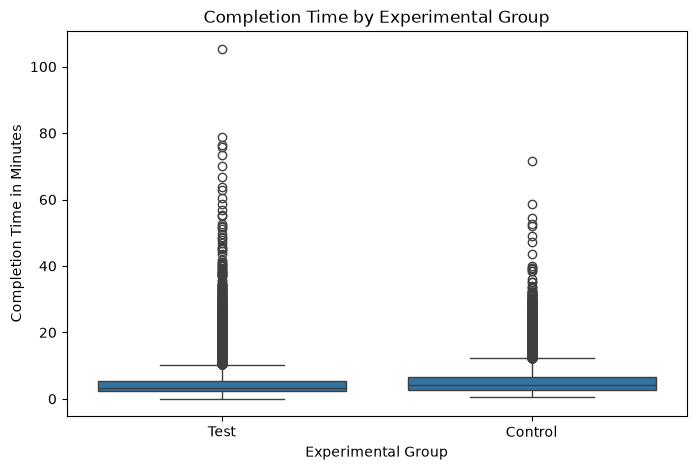

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=completion_analysis,
    x="Variation",
    y="completion_minutes"
)

plt.title("Completion Time by Experimental Group")
plt.xlabel("Experimental Group")
plt.ylabel("Completion Time in Minutes")

plt.show()

### Completion Time Interpretation

Completion time was measured at the journey level using only valid completed journeys that contained a Start followed by a Confirm event.

The Control group had a median completion time of 4.12 minutes, compared with 3.33 minutes for the Test group. Therefore, the typical completed journey in the Test group was approximately 0.78 minutes, or 47 seconds, faster than in the Control group.

The mean completion time was also lower for Test at 4.77 minutes compared with 5.41 minutes for Control.

The distributions contain exceptionally long journeys, producing right skew and making the mean more sensitive to extreme observations. Therefore, median completion time is used as the primary descriptive measure.

Using the IQR threshold established in Task 2, 9.28% of completed Control journeys and 7.13% of completed Test journeys were exceptionally long. These observations were retained because they represent genuine customer behaviour and may indicate friction or interruptions during the process.

Overall, the Test design is associated with faster completion and a lower proportion of exceptionally long completed journeys. Statistical testing will be required before concluding that the observed difference is statistically significant.

## Effective Time

### Purpose

Effective Time estimates how much time customers actively spend progressing through the expected digital process.

Unlike Completion Time, Effective Time does not simply measure the total elapsed duration from Start to Confirm. It focuses on the time associated with successful forward movement through the funnel.

### Analytical Unit

Effective Time is measured at the **completed journey level**.

### Included Observations

Only valid completed experimental journeys are included.

Incomplete journeys are excluded because they do not contain a complete forward progression ending in confirmation.

### Forward Progression

The expected progression is:

**Start → Step 1 → Step 2 → Step 3 → Confirm**

For each completed journey, the first valid occurrence of each next stage after the previous stage is used.

Repeated steps, backward movements and earlier failed attempts are not counted as additional forward progression time.

### Treatment of Waiting Periods

Time between consecutive valid forward stages is included because it represents the observed time required to progress from one stage to the next.

However, exceptionally long intervals may represent interruption or inactivity and will be investigated during KPI validation.

### Business Relevance

Effective Time provides a more focused measure of process efficiency than total Completion Time because it evaluates how quickly customers move through the required stages of the digital funnel.

In [69]:
effective_time_df = chronological_funnel[
    chronological_funnel["funnel_confirm_time"].notna()
].copy()

print("Completed chronological funnel journeys:", len(effective_time_df))

print(
    effective_time_df["Variation"].value_counts()
)

Completed chronological funnel journeys: 32414
Variation
Test       17731
Control    14683
Name: count, dtype: int64


In [70]:
effective_time_df["start_to_step_1"] = (
    effective_time_df["step_1_time"]
    - effective_time_df["start_time"]
).dt.total_seconds() / 60

effective_time_df["step_1_to_step_2"] = (
    effective_time_df["step_2_time"]
    - effective_time_df["step_1_time"]
).dt.total_seconds() / 60

effective_time_df["step_2_to_step_3"] = (
    effective_time_df["step_3_time"]
    - effective_time_df["step_2_time"]
).dt.total_seconds() / 60

effective_time_df["step_3_to_confirm"] = (
    effective_time_df["funnel_confirm_time"]
    - effective_time_df["step_3_time"]
).dt.total_seconds() / 60

In [71]:
effective_time_df["effective_minutes"] = (
    effective_time_df["start_to_step_1"]
    + effective_time_df["step_1_to_step_2"]
    + effective_time_df["step_2_to_step_3"]
    + effective_time_df["step_3_to_confirm"]
)

In [72]:
print(
    "Missing effective times:",
    effective_time_df["effective_minutes"].isna().sum()
)

print(
    "Zero or negative effective times:",
    (effective_time_df["effective_minutes"] <= 0).sum()
)

effective_time_df[
    [
        "start_to_step_1",
        "step_1_to_step_2",
        "step_2_to_step_3",
        "step_3_to_confirm",
        "effective_minutes"
    ]
].describe()

Missing effective times: 0
Zero or negative effective times: 0


,start_to_step_1,step_1_to_step_2,step_2_to_step_3,step_3_to_confirm,effective_minutes
count,32414.000000,32414.000000,32414.000000,32414.000000,32414.000000
mean,0.919294,1.075238,1.801948,2.589626,6.386105
std,3.012065,2.685033,2.939125,4.764631,7.406768
min,0.016667,0.033333,0.050000,0.200000,0.550000
25%,0.133333,0.216667,0.800000,0.633333,2.650000
50%,0.250000,0.450000,1.266667,1.200000,4.250000
75%,0.666667,0.933333,2.016667,2.616667,7.266667
max,187.016667,112.100000,299.583333,282.150000,300.250000


# Compare Effective Time by Test and Control

In [73]:
effective_time_summary = (
    effective_time_df
    .groupby("Variation")["effective_minutes"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

effective_time_summary.round(2)

,count,mean,median,std,min,max
Variation,,,,,,
Control,14683,6.52,4.53,7.04,0.55,284.53
Test,17731,6.27,3.97,7.70,0.60,300.25


In [74]:
control_effective_median = effective_time_df.loc[
    effective_time_df["Variation"] == "Control",
    "effective_minutes"
].median()

test_effective_median = effective_time_df.loc[
    effective_time_df["Variation"] == "Test",
    "effective_minutes"
].median()

effective_median_difference = (
    test_effective_median
    - control_effective_median
)

print(
    "Control median effective time:",
    round(control_effective_median, 2),
    "minutes"
)

print(
    "Test median effective time:",
    round(test_effective_median, 2),
    "minutes"
)

print(
    "Difference:",
    round(effective_median_difference, 2),
    "minutes"
)

Control median effective time: 4.53 minutes
Test median effective time: 3.97 minutes
Difference: -0.57 minutes


In [75]:
stage_time_summary = (
    effective_time_df
    .groupby("Variation")[
        [
            "start_to_step_1",
            "step_1_to_step_2",
            "step_2_to_step_3",
            "step_3_to_confirm"
        ]
    ]
    .median()
)

stage_time_summary.round(2)

,start_to_step_1,step_1_to_step_2,step_2_to_step_3,step_3_to_confirm
Variation,,,,
Control,0.35,0.37,1.32,1.50
Test,0.18,0.50,1.22,0.95


In [76]:
effective_q1 = effective_time_df["effective_minutes"].quantile(0.25)
effective_q3 = effective_time_df["effective_minutes"].quantile(0.75)

effective_iqr = effective_q3 - effective_q1

effective_upper_bound = (
    effective_q3 + 1.5 * effective_iqr
)

print("Q1:", round(effective_q1, 2))
print("Q3:", round(effective_q3, 2))
print("IQR:", round(effective_iqr, 2))
print(
    "Upper bound:",
    round(effective_upper_bound, 2),
    "minutes"
)

Q1: 2.65
Q3: 7.27
IQR: 4.62
Upper bound: 14.19 minutes


In [77]:
effective_time_df["exceptionally_long_effective"] = (
    effective_time_df["effective_minutes"]
    > effective_upper_bound
)

effective_long_summary = (
    effective_time_df
    .groupby("Variation")
    .agg(
        journeys=("visit_id", "count"),
        long_journeys=("exceptionally_long_effective", "sum")
    )
)

effective_long_summary["long_journey_rate"] = (
    effective_long_summary["long_journeys"]
    / effective_long_summary["journeys"]
    * 100
)

effective_long_summary.round(2)

,journeys,long_journeys,long_journey_rate
Variation,,,
Control,14683,1220,8.31
Test,17731,1460,8.23


### Effective Time Interpretation

Effective Time was measured at the journey level for completed journeys that followed the chronological funnel from Start through Confirm.

The Test group had a median effective time of 3.97 minutes compared with 4.53 minutes for the Control group. This represents a reduction of approximately 0.57 minutes, or 34 seconds, for the typical completed journey.

The improvement was not consistent across every stage. The Test group progressed faster from Start to Step 1, from Step 2 to Step 3, and particularly from Step 3 to Confirm. However, the Test group was slower from Step 1 to Step 2.

The Effective Time distribution was strongly right skewed. Using the IQR method, the upper bound for exceptionally long journeys was 14.19 minutes. Approximately 8.31% of Control journeys and 8.23% of Test journeys exceeded this threshold.

These exceptionally long journeys were retained because they may represent genuine customer behaviour rather than data errors. Since extreme values substantially affect the mean, the median is used as the primary descriptive measure of typical Effective Time.

Overall, the Test design appears to reduce the amount of time required for customers to actively progress through the funnel, particularly near the final confirmation stage. Statistical testing is required before determining whether this difference is statistically significant.

## Error Rate


Based on the methodology we established, we should not classify every repeated event as an error. A repeated page may simply mean that a customer revisited or refreshed a step.

A stronger behavioural definition is:

Error event = backward navigation through the expected funnel sequence.

For example, step_3 → step_2 is a backward movement and therefore a navigation difficulty signal.

We should calculate this at the journey level and include started experimental journeys, including abandoned journeys. This is important because customers experiencing navigation difficulties may be precisely the customers who fail to complete.

First, inspect the data we already created:

In [78]:
experiment_journey_df[
    [
        "visit_id",
        "Variation",
        "has_start",
        "has_confirm",
        "backward_navigation"
    ]
].head()

,visit_id,Variation,has_start,has_confirm,backward_navigation
0,100012776_37918976071_457913,Test,False,True,False
2,100019538_17884295066_43909,Test,True,True,True
3,100022086_87870757897_149620,Test,True,True,False
4,100030127_47967100085_936361,Control,True,False,False
6,100037962_47432393712_705583,Control,True,False,True


In [79]:
print(
    experiment_journey_df["backward_navigation"]
    .value_counts(dropna=False)
)

print()

print(
    experiment_journey_df
    .groupby("Variation")["backward_navigation"]
    .value_counts()
)

backward_navigation
False    52577
True     16447
Name: count, dtype: int64

Variation  backward_navigation
Control    False                  25526
           True                    6508
Test       False                  27051
           True                    9939
Name: count, dtype: int64


In [80]:
error_rate_df = experiment_journey_df[
    experiment_journey_df["has_start"]
].copy()

print("Started journeys:", len(error_rate_df))

print(
    error_rate_df["Variation"].value_counts()
)

Started journeys: 63790
Variation
Test       33022
Control    30768
Name: count, dtype: int64


In [81]:
error_summary = (
    error_rate_df
    .groupby("Variation")
    .agg(
        started_journeys=("visit_id", "count"),
        journeys_with_error=("backward_navigation", "sum")
    )
)

error_summary["error_rate"] = (
    error_summary["journeys_with_error"]
    / error_summary["started_journeys"]
    * 100
)

error_summary.round(2)

,started_journeys,journeys_with_error,error_rate
Variation,,,
Control,30768,6416,20.85
Test,33022,9865,29.87


### Error Rate Interpretation

Error Rate was measured at the journey level using started experimental journeys.

A journey was classified as having an error when it contained at least one backward navigation event. Each journey was counted once regardless of the number of backward movements. Incomplete journeys were retained because navigation difficulties may contribute to abandonment.

The Control group had an error rate of 20.85%, compared with 29.87% for the Test group. This represents an observed increase of 9.02 percentage points in the Test group.

Although the Test group achieved a higher completion rate, it also showed substantially more backward navigation. This suggests that the redesigned interface may improve overall completion while introducing additional navigation friction.

Statistical testing is required before concluding that the difference between the experimental groups is statistically significant.

## Step Backs

In [103]:
# STEP BACK ANALYSIS
# Step 1: Check available dataframes

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape)

__ (5, 4)
___ (30, 6)
web_clean_df (744641, 8)
experiment_clients_df (70609, 2)
visit_summary (158095, 5)
_12 (5, 5)
start_confirm_check (157398, 3)
_14 (5, 3)
both_events (77330, 3)
event_counts (158095, 5)
_16 (5, 5)
valid_event_counts (77267, 5)
completed_events (479933, 10)
valid_starts (107131, 10)
completion_pairs (77267, 4)
_21 (10, 3)
valid_confirms (86657, 9)
_23 (10, 3)
journey_df (158095, 13)
_25 (5, 9)
_26 (5, 12)
_27 (5, 13)
journey_patterns_df (10, 3)
_33 (10, 3)
long_completion (6059, 4)
experiment_journey_df (69024, 13)
started_journeys (63790, 13)
completion_summary (2, 3)
_41 (2, 3)
funnel_flags (63790, 6)
_44 (5, 6)
funnel_df (63790, 8)
_45 (5, 8)
funnel_events (308137, 8)
step_1_events (308137, 9)
step_2_events (308137, 9)
step_3_events (308137, 9)
confirm_events (308137, 9)
chronological_funnel (63790, 11)
_51 (5, 7)
funnel_summary (2, 5)
_55 (2, 5)
funnel_conversion (2, 5)
_56 (2, 5)
stage_conversion (2, 4)
_57 (2, 4)
dropoff_rates (2, 4)
_58 (2, 4)
completion_ana

In [106]:
# STEP BACK ANALYSIS
# Keep only clients with a valid experiment assignment
valid_experiment_clients = experiment_clients_df[
    experiment_clients_df["Variation"].isin(["Control", "Test"])
].copy()

step_back_df = web_clean_df.merge(
    valid_experiment_clients,
    on="client_id",
    how="inner",
    suffixes=("", "_experiment")
)

# Keep the experiment assignment from experiment_clients_df
if "Variation_experiment" in step_back_df.columns:
    step_back_df["Variation"] = step_back_df["Variation_experiment"]
    step_back_df = step_back_df.drop(
        columns=["Variation_experiment"]
    )

print("Experimental web events:", len(step_back_df))
print()

print(
    step_back_df["Variation"].value_counts(
        dropna=False
    )
)

print()
print(
    "Missing Variation:",
    step_back_df["Variation"].isna().sum()
)

step_back_df[
    [
        "client_id",
        "visitor_id",
        "visit_id",
        "process_step",
        "date_time",
        "Variation"
    ]
].head()

Experimental web events: 317235

Variation
Test       176699
Control    140536
Name: count, dtype: int64

Missing Variation: 0


,client_id,visitor_id,visit_id,process_step,date_time,Variation
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,Test
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,Test
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,Test
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,Test
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,Test


In [108]:
# Sort events chronologically within each journey

step_back_df = step_back_df.sort_values(
    ["client_id", "visit_id", "date_time"]
).reset_index(drop=True)

step_back_df[
    [
        "client_id",
        "visit_id",
        "Variation",
        "process_step",
        "date_time"
    ]
].head(10)

,client_id,visit_id,Variation,process_step,date_time
0,555,637149525_38041617439_716659,Test,start,2017-04-15 12:57:56
1,555,637149525_38041617439_716659,Test,step_1,2017-04-15 12:58:03
2,555,637149525_38041617439_716659,Test,step_2,2017-04-15 12:58:35
3,555,637149525_38041617439_716659,Test,step_3,2017-04-15 13:00:14
4,555,637149525_38041617439_716659,Test,confirm,2017-04-15 13:00:34
5,647,40369564_40101682850_311847,Test,start,2017-04-12 15:41:28
6,647,40369564_40101682850_311847,Test,step_1,2017-04-12 15:41:35
7,647,40369564_40101682850_311847,Test,step_2,2017-04-12 15:41:53
8,647,40369564_40101682850_311847,Test,step_3,2017-04-12 15:45:02
9,647,40369564_40101682850_311847,Test,confirm,2017-04-12 15:47:45


In [109]:

# Convert process steps into numerical order

step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

step_back_df["step_number"] = (
    step_back_df["process_step"].map(step_order)
)

print(
    "Missing step numbers:",
    step_back_df["step_number"].isna().sum()
)

step_back_df[
    [
        "client_id",
        "visit_id",
        "Variation",
        "process_step",
        "step_number",
        "date_time"
    ]
].head(10)

Missing step numbers: 0


,client_id,visit_id,Variation,process_step,step_number,date_time
0,555,637149525_38041617439_716659,Test,start,0,2017-04-15 12:57:56
1,555,637149525_38041617439_716659,Test,step_1,1,2017-04-15 12:58:03
2,555,637149525_38041617439_716659,Test,step_2,2,2017-04-15 12:58:35
3,555,637149525_38041617439_716659,Test,step_3,3,2017-04-15 13:00:14
4,555,637149525_38041617439_716659,Test,confirm,4,2017-04-15 13:00:34
5,647,40369564_40101682850_311847,Test,start,0,2017-04-12 15:41:28
6,647,40369564_40101682850_311847,Test,step_1,1,2017-04-12 15:41:35
7,647,40369564_40101682850_311847,Test,step_2,2,2017-04-12 15:41:53
8,647,40369564_40101682850_311847,Test,step_3,3,2017-04-12 15:45:02
9,647,40369564_40101682850_311847,Test,confirm,4,2017-04-12 15:47:45


In [110]:
# Identify backward navigation

step_back_df["previous_step"] = (
    step_back_df
    .groupby(["client_id", "visit_id"])["step_number"]
    .shift(1)
)

step_back_df["backward_navigation"] = (
    step_back_df["step_number"]
    < step_back_df["previous_step"]
)

print(
    step_back_df["backward_navigation"]
    .value_counts()
)

step_back_df[
    [
        "client_id",
        "visit_id",
        "Variation",
        "process_step",
        "step_number",
        "previous_step",
        "backward_navigation"
    ]
].head(15)

backward_navigation
False    291422
True      25813
Name: count, dtype: int64


,client_id,visit_id,Variation,process_step,step_number,previous_step,backward_navigation
0,555,637149525_38041617439_716659,Test,start,0,NaN,False
1,555,637149525_38041617439_716659,Test,step_1,1,0.0,False
2,555,637149525_38041617439_716659,Test,step_2,2,1.0,False
3,555,637149525_38041617439_716659,Test,step_3,3,2.0,False
4,555,637149525_38041617439_716659,Test,confirm,4,3.0,False
5,647,40369564_40101682850_311847,Test,start,0,NaN,False
6,647,40369564_40101682850_311847,Test,step_1,1,0.0,False
7,647,40369564_40101682850_311847,Test,step_2,2,1.0,False
8,647,40369564_40101682850_311847,Test,step_3,3,2.0,False
9,647,40369564_40101682850_311847,Test,confirm,4,3.0,False


In [111]:

# Count Step Backs per journey

step_back_journeys = (
    step_back_df
    .groupby(
        ["client_id", "visit_id", "Variation"],
        as_index=False
    )
    .agg(
        step_back_count=("backward_navigation", "sum")
    )
)

print(
    "Journey rows:",
    len(step_back_journeys)
)

print(
    "Unique client and visit combinations:",
    step_back_journeys[
        ["client_id", "visit_id"]
    ].drop_duplicates().shape[0]
)

print()

print(
    step_back_journeys["Variation"]
    .value_counts()
)

step_back_journeys.head()

Journey rows: 69447
Unique client and visit combinations: 69447

Variation
Test       37204
Control    32243
Name: count, dtype: int64


,client_id,visit_id,Variation,step_back_count
0,555,637149525_38041617439_716659,Test,0
1,647,40369564_40101682850_311847,Test,0
2,934,7076463_57954418406_971348,Test,0
3,1028,557292053_87239438319_391157,Control,2
4,1104,543158812_46395476577_767725,Control,0


In [112]:

# Calculate Step Back rate by variation

step_back_journeys["has_step_back"] = (
    step_back_journeys["step_back_count"] > 0
)

step_back_summary = (
    step_back_journeys
    .groupby("Variation")
    .agg(
        total_journeys=("visit_id", "count"),
        journeys_with_step_back=("has_step_back", "sum"),
        total_step_backs=("step_back_count", "sum")
    )
)

step_back_summary["step_back_rate"] = (
    step_back_summary["journeys_with_step_back"]
    / step_back_summary["total_journeys"]
    * 100
)

step_back_summary.round(2)

,total_journeys,journeys_with_step_back,total_step_backs,step_back_rate
Variation,,,,
Control,32243,6522,9581,20.23
Test,37204,9969,16232,26.80


In [114]:

# Two proportion Z test

from statsmodels.stats.proportion import proportions_ztest

control_step_backs = step_back_summary.loc[
    "Control",
    "journeys_with_step_back"
]

test_step_backs = step_back_summary.loc[
    "Test",
    "journeys_with_step_back"
]

control_total = step_back_summary.loc[
    "Control",
    "total_journeys"
]

test_total = step_back_summary.loc[
    "Test",
    "total_journeys"
]

count = [
    test_step_backs,
    control_step_backs
]

nobs = [
    test_total,
    control_total
]

z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative="two-sided"
)

alpha = 0.05

print("Z statistic:", round(z_stat, 4))
print("P value:", p_value)
print("Alpha:", alpha)

if p_value < alpha:
    print("Decision: Reject the null hypothesis")
else:
    print("Decision: Fail to reject the null hypothesis")

Z statistic: 20.2853
P value: 1.7329921780700512e-91
Alpha: 0.05
Decision: Reject the null hypothesis


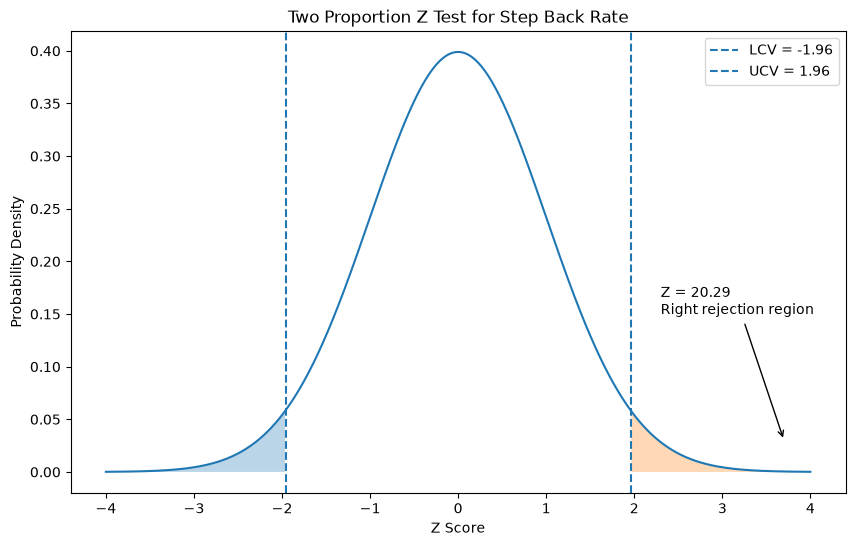

Alpha: 0.05
LCV: -1.96
UCV: 1.96
Z statistic: 20.2853
P value: 1.7329921780700512e-91
Decision: Reject the null hypothesis


In [115]:

#  Critical value visualization

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

alpha = 0.05

lcv = norm.ppf(alpha / 2)
ucv = norm.ppf(1 - alpha / 2)

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(10, 6))

plt.plot(x, y)

# Left rejection region
left_x = x[x <= lcv]
plt.fill_between(
    left_x,
    norm.pdf(left_x),
    alpha=0.3
)

# Right rejection region
right_x = x[x >= ucv]
plt.fill_between(
    right_x,
    norm.pdf(right_x),
    alpha=0.3
)

# Critical values
plt.axvline(
    lcv,
    linestyle="--",
    label=f"LCV = {lcv:.2f}"
)

plt.axvline(
    ucv,
    linestyle="--",
    label=f"UCV = {ucv:.2f}"
)

# Z statistic
# It is outside the displayed normal curve,
# so annotate its actual location.

plt.annotate(
    f"Z = {z_stat:.2f}\nRight rejection region",
    xy=(3.7, 0.03),
    xytext=(2.3, 0.15),
    arrowprops={"arrowstyle": "->"}
)

plt.title(
    "Two Proportion Z Test for Step Back Rate"
)

plt.xlabel("Z Score")
plt.ylabel("Probability Density")

plt.legend()
plt.show()

print("Alpha:", alpha)
print("LCV:", round(lcv, 2))
print("UCV:", round(ucv, 2))
print("Z statistic:", round(z_stat, 4))
print("P value:", p_value)
print("Decision: Reject the null hypothesis")

Conclusion: Reject the null hypothesis. There is a statistically significant difference in Step Back rates between the Test and Control groups. The Test group had a higher Step Back rate of 26.80%, compared with 20.23% for the Control group, a difference of 6.57 percentage points. This indicates that users in the Test design experienced significantly more backward navigation, suggesting increased friction in the redesigned process.

### Abandonment journey table
Identify every experimental journey that actually started and determine whether that same client and visit reached confirmation.

In [116]:
# ABANDONMENT RATE ANALYSIS
# Identify started and confirmed journeys

abandonment_df = (
    step_back_df
    .groupby(
        ["client_id", "visit_id", "Variation"],
        as_index=False
    )
    .agg(
        has_start=(
            "process_step",
            lambda x: (x == "start").any()
        ),
        has_confirm=(
            "process_step",
            lambda x: (x == "confirm").any()
        )
    )
)

# Keep only journeys that actually started
abandonment_df = abandonment_df[
    abandonment_df["has_start"]
].copy()

print(
    "Started journeys:",
    len(abandonment_df)
)

print()

print(
    abandonment_df["Variation"]
    .value_counts()
)

abandonment_df.head()

Started journeys: 64181

Variation
Test       33219
Control    30962
Name: count, dtype: int64


,client_id,visit_id,Variation,has_start,has_confirm
0,555,637149525_38041617439_716659,Test,True,True
1,647,40369564_40101682850_311847,Test,True,True
2,934,7076463_57954418406_971348,Test,True,False
3,1028,557292053_87239438319_391157,Control,True,False
4,1104,543158812_46395476577_767725,Control,True,False


In [117]:

#  Validate the journey population

print(
    "Started journey rows:",
    len(abandonment_df)
)

print(
    "Unique client and visit combinations:",
    abandonment_df[
        ["client_id", "visit_id"]
    ].drop_duplicates().shape[0]
)

print(
    "Missing Variation:",
    abandonment_df["Variation"].isna().sum()
)

print()

print(
    abandonment_df["Variation"]
    .value_counts()
)

print()

print(
    abandonment_df["has_confirm"]
    .value_counts()
)

Started journey rows: 64181
Unique client and visit combinations: 64181
Missing Variation: 0

Variation
Test       33219
Control    30962
Name: count, dtype: int64

has_confirm
True     32903
False    31278
Name: count, dtype: int64


In [118]:

# Identify abandoned journeys

abandonment_df["abandoned"] = (
    abandonment_df["has_start"]
    & ~abandonment_df["has_confirm"]
)

print(
    abandonment_df["abandoned"]
    .value_counts()
)

print()

print(
    abandonment_df
    .groupby("Variation")["abandoned"]
    .value_counts()
)

abandoned
False    32903
True     31278
Name: count, dtype: int64

Variation  abandoned
Control    True         16020
           False        14942
Test       False        17961
           True         15258
Name: count, dtype: int64


In [119]:

# Calculate abandonment rate

abandonment_summary = (
    abandonment_df
    .groupby("Variation")
    .agg(
        started_journeys=("visit_id", "count"),
        abandoned_journeys=("abandoned", "sum")
    )
)

abandonment_summary["abandonment_rate"] = (
    abandonment_summary["abandoned_journeys"]
    / abandonment_summary["started_journeys"]
    * 100
)

abandonment_summary.round(2)

,started_journeys,abandoned_journeys,abandonment_rate
Variation,,,
Control,30962,16020,51.74
Test,33219,15258,45.93


In [120]:
###Hypothesis Test for Abandonment Rate
# Two proportion Z test

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import norm

control_abandoned = 16020
control_started = 30962

test_abandoned = 15258
test_started = 33219

count = [
    test_abandoned,
    control_abandoned
]

nobs = [
    test_started,
    control_started
]

z_stat, p_value = proportions_ztest(
    count,
    nobs
)

alpha = 0.05

lcv = norm.ppf(alpha / 2)
ucv = norm.ppf(1 - alpha / 2)

print("Alpha:", alpha)
print("LCV:", round(lcv, 2))
print("UCV:", round(ucv, 2))
print("Z statistic:", round(z_stat, 4))
print("P value:", p_value)

if p_value < alpha:
    print("Decision: Reject the null hypothesis")
else:
    print("Decision: Fail to reject the null hypothesis")

Alpha: 0.05
LCV: -1.96
UCV: 1.96
Z statistic: -14.7129
P value: 5.3296210399045706e-49
Decision: Reject the null hypothesis


Abandonment Hypothesis Test


Measure	Result
Control abandonment rate	51.74%
Test abandonment rate	45.93%
Difference	5.81 percentage points lower in Test
Alpha	0.05
LCV	−1.96
UCV	1.96
Z statistic	−14.7129
P value	5.33 × 10⁻⁴⁹
Decision	Reject H0

Because −14.7129 is far below the lower critical value of −1.96, the test statistic falls deep inside the left rejection region.

The p value is also far below 0.05.

Therefore:

Reject the null hypothesis. There is statistically significant evidence that abandonment rates differ between the Test and Control groups. The Test group has a significantly lower abandonment rate, 45.93%, compared with 51.74% for Control.

Business interpretation

This is a meaningful result.

The Test design reduced abandonment by:

51.74% − 45.93% = 5.81 percentage points

The relative reduction is approximately:

5.81 ÷ 51.74 × 100 = 11.23%

the Test experience produced approximately an 11.2% relative reduction in journey abandonment compared with Control.

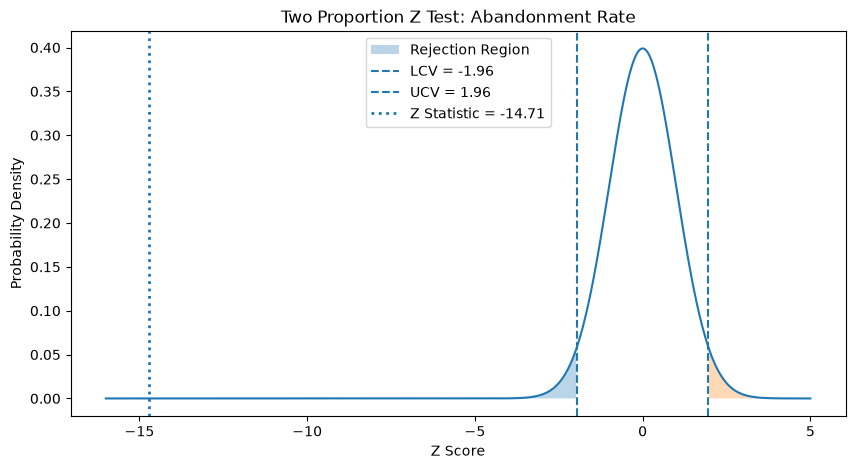

In [121]:

# Critical value visualization

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-16, 5, 1000)
y = norm.pdf(x)

plt.figure(figsize=(10, 5))

plt.plot(x, y)

# Rejection regions
plt.fill_between(
    x,
    y,
    where=(x <= lcv),
    alpha=0.3,
    label="Rejection Region"
)

plt.fill_between(
    x,
    y,
    where=(x >= ucv),
    alpha=0.3
)

# Critical values
plt.axvline(
    lcv,
    linestyle="--",
    label=f"LCV = {lcv:.2f}"
)

plt.axvline(
    ucv,
    linestyle="--",
    label=f"UCV = {ucv:.2f}"
)

# Test statistic
plt.axvline(
    z_stat,
    linestyle=":",
    linewidth=2,
    label=f"Z Statistic = {z_stat:.2f}"
)

plt.title("Two Proportion Z Test: Abandonment Rate")
plt.xlabel("Z Score")
plt.ylabel("Probability Density")

plt.legend()
plt.show()

Reject H0. The Test and Control abandonment rates are statistically significantly different. The Test group has a significantly lower abandonment rate of 45.93% compared with 51.74% for Control.

### Abandonment Rate Interpretation

The Control group had an abandonment rate of 51.74%, compared with 45.93% for the Test group. This represents a 5.81 percentage point reduction in abandonment for the Test experience.

A two proportion Z test was used to determine whether the difference was statistically significant.

H0: The abandonment rates of the Test and Control groups are equal.

H1: The abandonment rates of the Test and Control groups are different.

At an alpha level of 0.05, the critical values were -1.96 and 1.96. The test produced a Z statistic of -14.71 and a p value far below 0.05.

The test statistic falls in the left rejection region. Therefore, the null hypothesis is rejected.

The results provide strong statistical evidence that the Test design reduced journey abandonment compared with the Control design.

# KPI VALIDATION

In [122]:

#  Validate completion rate

completion_validation = (
    abandonment_df
    .groupby("Variation")
    .agg(
        started_journeys=("visit_id", "count"),
        completed_journeys=("has_confirm", "sum")
    )
)

completion_validation["completion_rate"] = (
    completion_validation["completed_journeys"]
    / completion_validation["started_journeys"]
    * 100
)

completion_validation["not_completed"] = (
    completion_validation["started_journeys"]
    - completion_validation["completed_journeys"]
)

completion_validation.round(2)

,started_journeys,completed_journeys,completion_rate,not_completed
Variation,,,,
Control,30962,14942,48.26,16020
Test,33219,17961,54.07,15258


In [123]:
completion_validation["rate_check"] = (
    completion_validation["completion_rate"]
    + abandonment_summary["abandonment_rate"]
)

completion_validation[
    ["completion_rate", "rate_check"]
].round(2)

,completion_rate,rate_check
Variation,,
Control,48.26,100.0
Test,54.07,100.0


In [124]:

#  Validate completion time distribution

completion_analysis[
    "completion_minutes"
].describe()

count    32561.000000
mean         5.060058
std          4.635891
min          0.083333
25%          2.383333
50%          3.650000
75%          5.966667
max        105.450000
Name: completion_minutes, dtype: float64

In [125]:
completion_analysis.groupby(
    "Variation"
)["completion_minutes"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,14784.0,5.41,4.4,0.55,2.68,4.12,6.52,71.55
Test,17777.0,4.77,4.8,0.08,2.22,3.33,5.47,105.45


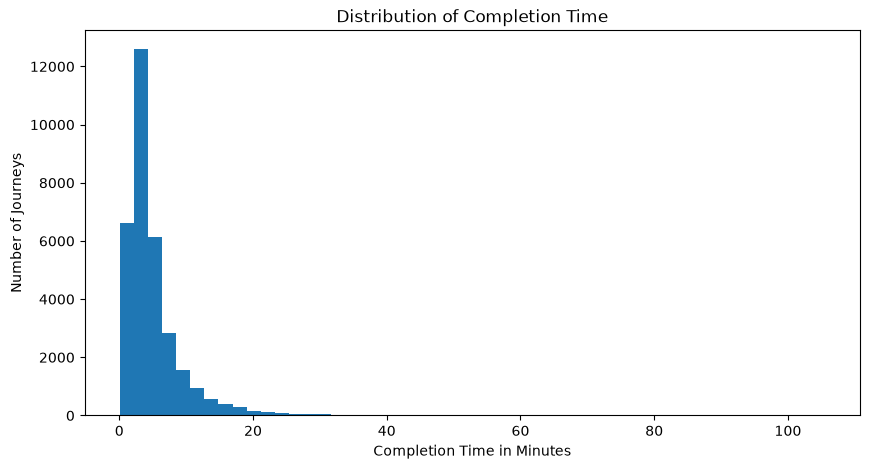

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    completion_analysis["completion_minutes"],
    bins=50
)

plt.title("Distribution of Completion Time")
plt.xlabel("Completion Time in Minutes")
plt.ylabel("Number of Journeys")

plt.show()

histogram is strongly right skewed. Most completed journeys are concentrated below roughly 10 minutes, while a relatively small number extend much farther to the right.

The descriptive statistics support that:

| Metric  |    Overall |   Control |       Test |
| ------- | ---------: | --------: | ---------: |
| Mean    |   5.06 min |  5.41 min |   4.77 min |
| Median  |   3.65 min |  4.12 min |   3.33 min |
| Q1      |   2.38 min |  2.68 min |   2.22 min |
| Q3      |   5.97 min |  6.52 min |   5.47 min |
| Maximum | 105.45 min | 71.55 min | 105.45 min |


In [147]:
print(
    "Unique clients:",
    client_journey_count["client_id"].nunique()
)

print()

client_journey_count[
    "journey_count"
].describe()

Unique clients: 50076



count    50076.000000
mean         1.281672
std          0.687090
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         18.000000
Name: journey_count, dtype: float64

# Client Level

In [146]:
# Count started journeys per client

client_journey_count = (
    abandonment_df
    .groupby(["client_id", "Variation"])
    .size()
    .reset_index(name="journey_count")
)

client_journey_count.head()

,client_id,Variation,journey_count
0,555,Test,1
1,647,Test,1
2,934,Test,1
3,1028,Control,1
4,1104,Control,2


In [148]:
client_journey_count.groupby(
    "Variation"
)["journey_count"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,23397.0,1.32,0.77,1.0,1.0,1.0,1.0,18.0
Test,26679.0,1.25,0.60,1.0,1.0,1.0,1.0,12.0


In [149]:
client_completion = (
    abandonment_df
    .groupby(["client_id", "Variation"])
    .agg(
        started_journeys=("visit_id", "nunique"),
        completed_any=("has_confirm", "max")
    )
    .reset_index()
)

client_completion.head()

,client_id,Variation,started_journeys,completed_any
0,555,Test,1,True
1,647,Test,1,True
2,934,Test,1,False
3,1028,Control,1,False
4,1104,Control,2,False


In [150]:
client_completion_summary = (
    client_completion
    .groupby("Variation")
    .agg(
        clients=("client_id", "nunique"),
        clients_completed=("completed_any", "sum")
    )
)

client_completion_summary["client_completion_rate"] = (
    client_completion_summary["clients_completed"]
    / client_completion_summary["clients"]
    * 100
)

client_completion_summary.round(2)

,clients,clients_completed,client_completion_rate
Variation,,,
Control,23397,14919,63.76
Test,26679,17906,67.12


In [151]:
client_journey_count = (
    abandonment_df
    .groupby(["client_id", "Variation"])
    .size()
    .reset_index(name="journey_count")
)

print(
    "Unique clients:",
    client_journey_count["client_id"].nunique()
)

client_journey_count[
    "journey_count"
].describe()

Unique clients: 50076


count    50076.000000
mean         1.281672
std          0.687090
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         18.000000
Name: journey_count, dtype: float64

### Client Level KPI Validation

Because the experiment is assigned at the client level while the primary KPIs are calculated at the journey level, an additional client level validation was performed.

Among clients with at least one started journey, 50,076 unique clients were identified. Most clients had only one started journey, although some clients made repeated attempts.

Control clients averaged 1.32 started journeys, compared with 1.25 for Test clients.

At the client level, 63.76% of Control clients completed at least one journey, compared with 67.12% of Test clients.

This supports the direction of the journey level completion KPI, where Test also demonstrated a higher completion rate.

The higher client level completion rates are expected because clients with multiple attempts are counted once and are considered successful if at least one journey reaches confirmation.

The client level validation therefore indicates that the higher completion performance observed in the Test group is not solely driven by repeated customer journeys.

In [153]:
# Find DataFrames containing client_id and Variation

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if "client_id" in obj.columns and "Variation" in obj.columns:
            print(name, obj.shape)

___ (5, 4)
experiment_clients_df (70609, 2)
journey_df (158095, 13)
_27 (5, 13)
experiment_journey_df (69024, 13)
started_journeys (63790, 13)
completion_analysis (32561, 16)
_61 (5, 14)
error_rate_df (63790, 13)
step_back_df (317235, 9)
step_back_journeys (69447, 6)
duplicate_visits (474, 4)
_87 (0, 2)
_89 (30, 6)
_90 (5, 4)
_92 (20, 4)
_95 (0, 2)
_97 (30, 6)
_98 (5, 4)
_104 (5, 9)
_105 (5, 9)
valid_experiment_clients (50500, 2)
_106 (5, 6)
_107 (10, 5)
_108 (10, 5)
_109 (10, 6)
_110 (15, 7)
_111 (5, 4)
abandonment_df (64181, 6)
_116 (5, 5)
completion_outliers (2423, 15)
_130 (10, 4)
client_journey_count (50076, 3)
_143 (5, 3)
_146 (5, 3)
client_completion (50076, 4)
_149 (5, 4)


In [155]:
# Find experimental clients without a started journey

started_client_ids = client_completion["client_id"].unique()

clients_without_start = valid_experiment_clients[
    ~valid_experiment_clients["client_id"].isin(started_client_ids)
].copy()

print(
    "Experimental clients:",
    valid_experiment_clients["client_id"].nunique()
)

print(
    "Clients with a started journey:",
    client_completion["client_id"].nunique()
)

print(
    "Clients without a started journey:",
    clients_without_start["client_id"].nunique()
)

print()

print("Clients without a started journey by variation:")

print(
    clients_without_start["Variation"]
    .value_counts()
)

Experimental clients: 50500
Clients with a started journey: 50076
Clients without a started journey: 424

Clients without a started journey by variation:
Variation
Test       289
Control    135
Name: count, dtype: int64


### Clients Without an Observed Start

The full experimental population contains 50,500 clients. Of these, 50,076 clients had at least one identifiable started journey, while 424 clients had no observed start event.

The clients without an observed start consisted of 289 Test clients and 135 Control clients.

This represents approximately 1.07% of Test clients and 0.57% of Control clients.

These clients were not classified as abandoned because the abandonment KPI is conditional on an observed process start. They were therefore excluded from the completion and abandonment denominators.

The relatively small number of clients without a start does not materially change the primary journey based KPI population, although the higher no start proportion in the Test group should be documented as a limitation and may warrant separate investigation.

# Identify Completion Time Outliers

In [127]:

# Identify completion time outliers

q1 = completion_analysis["completion_minutes"].quantile(0.25)
q3 = completion_analysis["completion_minutes"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))

Q1: 2.38
Q3: 5.97
IQR: 3.58
Lower bound: -2.99
Upper bound: 11.34


In [128]:
completion_outliers = completion_analysis[
    (completion_analysis["completion_minutes"] < lower_bound)
    | (completion_analysis["completion_minutes"] > upper_bound)
].copy()

print(
    "Number of outliers:",
    len(completion_outliers)
)

print(
    "Outlier percentage:",
    round(
        len(completion_outliers)
        / len(completion_analysis)
        * 100,
        2
    ),
    "%"
)

Number of outliers: 2423
Outlier percentage: 7.44 %


In [129]:
completion_outliers.groupby(
    "Variation"
).size()

Variation
Control    1249
Test       1174
dtype: int64

In [130]:
completion_outliers[
    [
        "client_id",
        "visit_id",
        "Variation",
        "completion_minutes"
    ]
].sort_values(
    "completion_minutes",
    ascending=False
).head(10)

,client_id,visit_id,Variation,completion_minutes
88095,4053786,602830065_65703315740_227601,Test,105.450000
79623,9410549,554897609_58242917017_669621,Test,78.850000
113667,3504849,747021435_81971404693_967845,Test,76.500000
140570,6229511,901045687_93987650598_395894,Test,75.800000
73285,1595223,51853936_4251561986_994623,Test,73.350000
88801,9664057,606933856_27920340849_118462,Control,71.550000
9981,847220,15715423_17683599671_815762,Test,70.066667
55354,1718738,416458625_8244365553_56895,Test,66.816667
58105,6430825,431726902_86731111588_474118,Test,63.850000
120521,8442995,786583103_56983830327_743390,Test,62.933333


# Validation Result

IQR analysis found:

Measure	Result
Q1	2.38 minutes
Q3	5.97 minutes
IQR	3.58 minutes
Upper bound	11.34 minutes
Outliers	2,423
Outlier percentage	7.44%
Control outliers	1,249
Test outliers	1,174
Maximum	105.45 minutes

The negative lower bound of negative 2.99 minutes is not a concern because the observed completion times are positive. Therefore, the practical outliers are journeys above 11.34 minutes.

Important observation

Raw counts alone could be misleading because the Test and Control groups have different numbers of completed journeys.

# Compare Outlier Rates

In [131]:
completion_analysis["completion_outlier"] = (
    completion_analysis["completion_minutes"] > upper_bound
)

completion_outlier_summary = (
    completion_analysis
    .groupby("Variation")
    .agg(
        completed_journeys=("visit_id", "count"),
        outlier_journeys=("completion_outlier", "sum")
    )
)

completion_outlier_summary["outlier_rate"] = (
    completion_outlier_summary["outlier_journeys"]
    / completion_outlier_summary["completed_journeys"]
    * 100
)

completion_outlier_summary.round(2)

,completed_journeys,outlier_journeys,outlier_rate
Variation,,,
Control,14784,1249,8.45
Test,17777,1174,6.60


### Validation Result

| Variation | Completed journeys | Outlier journeys | Outlier rate |
| :-------- | -----------------: | ---------------: | -----------: |
| Control   |             14,784 |            1,249 |        8.45% |
| Test      |             17,777 |            1,174 |        6.60% |
The Test group has a lower proportion of exceptionally long completion journeys.

Control has an outlier rate of 8.45%, compared with 6.60% for Test, a difference of 1.85 percentage points.

This supports what the already observed in the completion time distribution. The Test experience generally appears faster, and unusually long completion journeys are also less frequent.

### Completion Time Outlier Validation

Completion time is strongly right skewed, with most customers completing the process within a relatively short period and a smaller number taking substantially longer.

Using the IQR method, completion times above 11.34 minutes were classified as potential outliers. A total of 2,423 journeys, or 7.44% of completed journeys, were identified as outliers.

The Control group had an outlier rate of 8.45%, compared with 6.60% for the Test group. This indicates that unusually long completion journeys occurred less frequently in the Test experience.

These observations were retained because long completion times may represent genuine customer behaviour, such as customers pausing during the process. Removing them could hide meaningful usability behaviour. Because the distribution is right skewed and contains outliers, the median should be considered alongside the mean when interpreting completion time.

### Validation: Step Back distribution

In [132]:
step_back_journeys["step_back_count"].describe()

count    69447.000000
mean         0.371694
std          0.845854
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         25.000000
Name: step_back_count, dtype: float64

In [133]:
step_back_journeys.groupby(
    "Variation"
)["step_back_count"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,32243.0,0.30,0.72,0.0,0.0,0.0,0.0,11.0
Test,37204.0,0.44,0.94,0.0,0.0,0.0,1.0,25.0


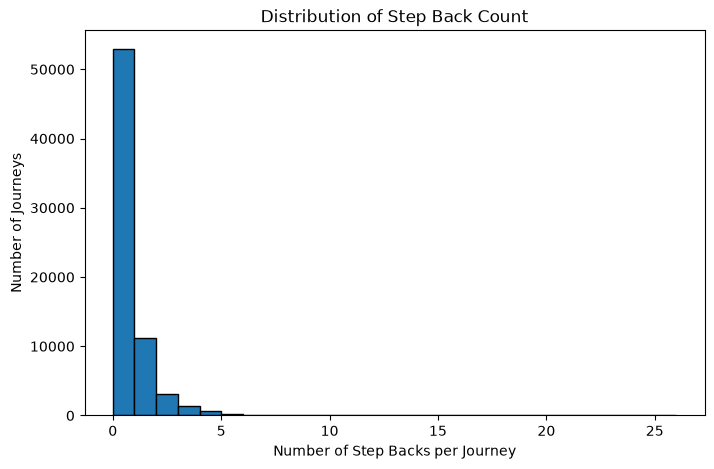

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    step_back_journeys["step_back_count"],
    bins=range(
        0,
        int(step_back_journeys["step_back_count"].max()) + 2
    ),
    edgecolor="black"
)

plt.title("Distribution of Step Back Count")
plt.xlabel("Number of Step Backs per Journey")
plt.ylabel("Number of Journeys")

plt.show()

# Step Back Distribution Validation
| Metric          | Overall | Control |   Test |
| :-------------- | ------: | ------: | -----: |
| Journeys        |  69,447 |  32,243 | 37,204 |
| Mean step backs |    0.37 |    0.30 |   0.44 |
| Median          |       0 |       0 |      0 |
| Q3              |       0 |       0 |      1 |
| Maximum         |      25 |      11 |     25 |
The histogram confirms that most journeys have zero step backs, while a much smaller number contain repeated backward navigation.

There is also a clear difference between the groups. Test has a higher average step back count of 0.44 versus 0.30, and its upper quartile is 1 rather than 0. The Test group also contains the most extreme observed journey with 25 step backs.

## Investigate Repeated Step Backs

We want to distinguish:

Any step back: at least 1

Repeated step backs: at least 2

High repeated step backs: at least 5

In [135]:
step_back_journeys["step_back_category"] = pd.cut(
    step_back_journeys["step_back_count"],
    bins=[-1, 0, 1, 4, float("inf")],
    labels=[
        "No Step Back",
        "1 Step Back",
        "2 to 4 Step Backs",
        "5 or More Step Backs"
    ]
)

step_back_category_summary = pd.crosstab(
    step_back_journeys["Variation"],
    step_back_journeys["step_back_category"],
    normalize="index"
) * 100

step_back_category_summary.round(2)

step_back_category,No Step Back,1 Step Back,2 to 4 Step Backs,5 or More Step Backs
Variation,,,,
Control,79.77,14.17,5.74,0.32
Test,73.20,17.62,8.44,0.73


### Step Back Distribution Validation

The step back count is strongly right skewed and zero inflated. Most customer journeys contain no backward navigation.

The median step back count is 0 for both groups. However, the Test group has a higher mean step back count of 0.44 compared with 0.30 for Control. The third quartile is also higher for Test at 1 step back compared with 0 for Control.

The maximum number of step backs was 25 for Test and 11 for Control, indicating that a small number of customers experienced substantial repeated backward navigation.

The standard IQR method is not appropriate for identifying outliers for this KPI because both Q1 and Q3 are 0 for the overall distribution, producing an IQR of 0. This would incorrectly classify every journey containing a step back as an outlier.

Therefore, step backs are retained as meaningful behavioural observations and repeated backward navigation is investigated separately.

### Step Back Behaviour Interpretation

Most journeys contained no backward navigation. However, step back behaviour was consistently more common in the Test group.

In the Control group, 79.77% of journeys had no step backs, compared with 73.20% in the Test group.

The Test group also had higher proportions of journeys with one step back, 2 to 4 step backs, and 5 or more step backs. In particular, journeys with 5 or more step backs represented 0.73% of Test journeys compared with 0.32% of Control journeys.

This indicates that the higher step back rate in the Test group is not caused only by a small number of extreme journeys. Backward navigation is more broadly distributed across Test journeys.

The result suggests that although the Test design improves completion and reduces completion time, some parts of the redesigned process may create additional navigation difficulty or encourage customers to revisit previous steps.

# Where our KPI validation stands

We now have a very interesting tradeoff:

# Test performs better on conversion

Completion rate increased from 48.26% to 54.07%.

# Test performs better on abandonment

Abandonment decreased from 51.74% to 45.93%.

# Test performs better on completion time

Median completion time is lower, and completion time outliers are less common at 6.60% versus 8.45%.

# But Test performs worse on step backs

Step back rate is 26.80% versus 20.23%, and repeated backward navigation is also more common.

That is already becoming a strong business story: the redesigned experience appears more effective and generally faster, but it may introduce additional navigation friction.

## KPI Validation Conclusion

Overall, the KPIs provide a reasonable representation of customer behaviour during the experiment.

Completion rate and abandonment rate are internally consistent, with the two measures summing to 100% for started journeys. The Test group achieved a higher completion rate and a lower abandonment rate than the Control group.

Completion time is strongly right skewed and contains unusually long journeys. Therefore, the median is considered alongside the mean to avoid allowing extreme values to dominate the interpretation. These long journeys were retained because they may represent genuine customer behaviour, such as customers pausing during the process.

Step back behaviour is also strongly right skewed and zero inflated. Most journeys contain no backward navigation. The standard IQR method is not appropriate for this KPI because it would classify every journey with a step back as an outlier. Instead, repeated step backs were examined separately.

The Test group shows better completion, lower abandonment, and generally faster completion. However, it also shows more backward navigation. This suggests that the new design improves overall funnel effectiveness while potentially introducing navigation friction at some stages.

The KPIs therefore represent customer behaviour reasonably well within the methodological assumptions used in this analysis. However, they should be interpreted together rather than individually because no single KPI fully captures the customer experience.

## 5. Prepare for Statistical Analysis

The customer journey KPIs have been reconstructed and validated at the journey level. Before performing formal A/B testing, the final metrics are reviewed to confirm that the analytical data is complete and appropriate for statistical comparison.

The primary KPIs are:

1. Completion Rate
2. Completion Time
3. Step Back Rate
4. Abandonment Rate

These KPIs will be compared between the Control and Test groups in the statistical analysis.

# Final KPI Review Table
Create one simple table showing the main Control and Test results we will carry forward.

In [137]:
kpi_review = pd.DataFrame({
    "Control": [
        completion_validation.loc["Control", "completion_rate"],
        completion_analysis.loc[
            completion_analysis["Variation"] == "Control",
            "completion_minutes"
        ].median(),
        step_back_summary.loc["Control", "step_back_rate"],
        abandonment_summary.loc["Control", "abandonment_rate"]
    ],
    "Test": [
        completion_validation.loc["Test", "completion_rate"],
        completion_analysis.loc[
            completion_analysis["Variation"] == "Test",
            "completion_minutes"
        ].median(),
        step_back_summary.loc["Test", "step_back_rate"],
        abandonment_summary.loc["Test", "abandonment_rate"]
    ]
}, index=[
    "Completion Rate (%)",
    "Median Completion Time (Minutes)",
    "Step Back Rate (%)",
    "Abandonment Rate (%)"
])

kpi_review.round(2)

,Control,Test
Completion Rate (%),48.26,54.07
Median Completion Time (Minutes),4.12,3.33
Step Back Rate (%),20.23,26.80
Abandonment Rate (%),51.74,45.93


In [141]:
# Verify Final Analytical Dataset Completeness

print("Experiment clients:", len(experiment_clients_df))
print()

print("Completion and abandonment journeys:", len(abandonment_df))
print(
    "Missing variation:",
    abandonment_df["Variation"].isna().sum()
)

print()

print("Completion time observations:", len(completion_analysis))
print(
    "Missing completion times:",
    completion_analysis["completion_minutes"].isna().sum()
)

print()

print("Step back journeys:", len(step_back_journeys))
print(
    "Missing step back counts:",
    step_back_journeys["step_back_count"].isna().sum()
)

print()

print("Completion and abandonment population:")
print(abandonment_df["Variation"].value_counts())

print()

print("Step back population:")
print(step_back_journeys["Variation"].value_counts())

print()

print("Completion time population:")
print(completion_analysis["Variation"].value_counts())

Experiment clients: 70609

Completion and abandonment journeys: 64181
Missing variation: 0

Completion time observations: 32561
Missing completion times: 0

Step back journeys: 69447
Missing step back counts: 0

Completion and abandonment population:
Variation
Test       33219
Control    30962
Name: count, dtype: int64

Step back population:
Variation
Test       37204
Control    32243
Name: count, dtype: int64

Completion time population:
Variation
Test       17777
Control    14784
Name: count, dtype: int64


In [140]:
# Find dataframes matching the final abandonment population

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if len(obj) == 64181:
            print(name, obj.shape)
            print(obj.columns.tolist())
            print()

abandonment_df (64181, 6)
['client_id', 'visit_id', 'Variation', 'has_start', 'has_confirm', 'abandoned']



### Statistical Analysis Preparation

The validated KPIs will be compared between the Control and Test groups.

#### Completion Rate

Completion is a binary outcome indicating whether a started journey reached confirmation.

A two proportion Z test is appropriate because the analysis compares completion proportions between two independent experimental groups. The sample sizes are large enough for the normal approximation.

#### Completion Time

Completion time is a continuous variable measured only for journeys with a valid start and confirmation.

The distribution is right skewed and contains outliers. Before selecting the final statistical test, normality and other relevant assumptions will be evaluated. A nonparametric test may be more appropriate if the assumptions for a parametric comparison are not satisfied.

#### Step Back Rate

Step back rate is a binary journey level outcome indicating whether a journey contains at least one backward navigation event.

A two proportion Z test is appropriate for comparing the proportion of journeys with step back behaviour between the Control and Test groups.

#### Abandonment Rate

Abandonment is a binary outcome indicating whether a started journey failed to reach confirmation.

A two proportion Z test is appropriate for comparing abandonment proportions between the Control and Test groups.

Completion and abandonment are complementary under the methodology used in this analysis. Therefore, they describe the same underlying journey outcome from opposite perspectives and should not be interpreted as independent statistical outcomes.

#### Assumptions to Check

1. Control and Test groups represent independent experimental groups.
2. Each analytical observation represents one defined customer journey.
3. Binary KPI sample sizes are sufficiently large for proportion based statistical tests.
4. Completion time should be checked for distribution shape, normality and outliers before selecting the statistical test.
5. Extreme completion times should be investigated rather than automatically removed.
6. Statistical significance should be considered together with effect size and business relevance.

### Statistical Analysis Readiness

The KPI datasets are complete and ready for statistical comparison.

The final analytical populations differ because each KPI has a specific eligibility definition. Completion and abandonment are measured among started journeys, completion time is measured only among valid completed journeys, and step back behaviour is measured across experiment journeys with observable navigation sequences.

No missing values were identified in the variables required for the planned comparisons.

The next stage will formally compare the Control and Test groups using appropriate statistical tests, including hypothesis formulation, significance level, critical values, test statistics, p values, effect sizes and final statistical decisions.